## WP2.2 
### normalisation and standardisation of water quality measures. 

#### A: Instrument  to Intrument harmonisation:

PROCESS:

1. generate **daily** results for some sites, e.g. for the years 2019 & 2020 (all instruments available), and:
   - Save the results as cumulative distributions for all variables for all sites
     
   **-- COMPLETED --**
3. Compile and compare results for the same algorithm, between sensors, i.e,. :
   - NDVI ETM v. NDVI OLI v. NDVI MSI, and:
   - Select a REFERENCE measurement (usually the MSI version) for each measurement
     
    **-- COMPLETED --**
4. Determine offsets or adjustments to reach the reference (a function), and:
   - save functions that adjust for sensor differences
    **-- COMPLETED --**
5. (Choose sites to ***be re-used for calibration against in-situ data*** (e.g. lake victoria)

WHY IS THIS NEEDED?:

1. Multi-year time-series results will not be valid unless these corrections are made, because results are biased from one sensor to another.
   
Move on to harmonisation between measurements

 
#### B: Measurement to Measurement harmonisation :
1. generate results for all sites
   - results include the observed distribution of each WQ variable - this is in quantiles
    **-- COMPLETED --**
     
2. compile results to a single dataset
    **-- COMPLETED --**
3. choose a reference measurement
    **-- COMPLETED i think --**
4. determine the adjustment parameters to adjust other measures to the statistical space of the reference measure
   - this includes the **time intervals** to use 
   - Simplest case: match the medians and the 1% quantile **for all times and places**
   - COMPLETED
   - More sophisticated : match probability distributions to an ensemble model (pending)
     
5. Save results to csv files

   - COMPLETED


C: calibration against other data (n-situ)

In [929]:
# ---  dependencies --- 
import os
import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gcf
import json
from scipy import stats
import pandas as pd     #for dates
from odc.ui import image_aspect
from deafrica_tools.plotting import rgb # used in some visualisation for debugging
dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [931]:
# --- pathnames 
# results files are stored in my space for now
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
WP12              = '/home/jovyan/dev/deafrica_water_quality/WP1.2/'
WP22              = '/home/jovyan/dev/deafrica_water_quality/WP2.2/'
data_directory    = '/home/jovyan/dev/deafrica_water_quality/src/water_quality/data/'
all_results_filename    = 'wq_raw'
annual_results_filename  = 'annsummary'
parta_results_filename   = '22A'
partc_results_filename   = '22C'
distributions_filename = 'measurment_distributions.nc'
lookup_table_filename  = 'targ_ref_lookup.csv'
np_parameters_filename = 'normalisation_parameters.csv'


In [932]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [4]:
set_spacetime_domain('HC_1')

({'x': (30.5, 30.7), 'y': (-8.0, -7.8), 'time': ('2000', '2024')},
 (10, 10),
 0.0001,
 'bilinear',
 '2000',
 '2024')

# Part A, Instrument to Instrument Harmonisation

## A1 : Build datasets from daily observations for key sites

- as well as the primary data, we are going to need wofs to determine water areas, and the geomedians to help filter outliers (perhaps).

#### Parameters -- including a list of places to process 
- parameters are needed for the accompanying geomedian datasets too
  

In [4]:
# --- controlling parameters and settings 
verbose = True 
test    = False
# --- the number of cells in the spatial domain (x,y) used to analyse the waterbody ; Data are resampled guided by this limit 
max_cells = 100000   
max_cells = 50000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 10000   #use this to test memory limits. Memory saving steps are going to be needed...
year1, year2 = '2019-01-01','2020-12-31' #this is a good start interval for instrument cross-referencing

# --- get the dictionary of all possible places for analysis ---
places_dict     = set_spacetime_domain()   
process_list = ['Lake_Baringo', 
           'Senegal_StLouis', 
           'Lake_Sulunga', 'Lake_Mweru',
            'Ghana_River', 
            'Lake_vic_turbid', 
            'Morocco', 
            'Thewaterskool_SA',
            'Ethiopia1of2', 
            'Ethiopia2of2', 
            'Ethiopia3of2',
            'SA_smalldam',
            'Lake Chamo', 
            'Lake Ziway', 
            'Lake Alwassa',
            'mombasa', 
            'Lake_Nasser_nth',
            'Lake_Nasser_sth',
            'Lake_Malawi',
            'Barrage Joumine', 
            'Lake_Chilwa', 'Lake_Malombe',
#            'Indian_Ocean',
            'Haartbeesport_dam', 'Lake Bogoria',
            'HC_1',
            'HC_2',
            'HC_3',
            'HC_4',
            'HC_5',
            'HC_6']

In [5]:
# --- dictionaries for the non-geomedian instruments and products ...
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

# for the non-geomedian datasets, the build function wants to know the products ... 
instruments_to_use = check_instrument_dates(instruments_to_use,
                                            pd.DatetimeIndex([year1]).year[0],
                                            pd.DatetimeIndex([year2]).year[0],False)
products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments,measurements,rename_dict = instruments_list(instruments_to_use) 
data_list = {}

In [6]:
# start a log file
logfilename = 'parta_log.csv'
a_log = open_logfile(places_dict,
                     logfilename,
                     overwrite='False',   # alternatively use True or False
                     include_list=process_list)

#reduce the log file to the places we are specifically interested in; this seems messy
droplist = list(set(a_log.PlaceName) - set(process_list))

for name in droplist:   a_log.drop(a_log[a_log.PlaceName==name].index,inplace=True)
a_log.reset_index(inplace=True,drop=True)

#### RUN THE MAIN PROCESS - this takes hours and requires a large sandbox 
- Results are generated for a 10-year geomedian series, and
- A 1-year full-data series
- The full data series allows comparison of TM, OLI and MSI results for a common period.
- The full detail is required because the geomedians don't overlap in time.  

In [30]:
#possibly re-run lake bogoria to visualise results for comparison with others
a_log.loc[(a_log.PlaceName=='Lake Bogoria','Status')]=0

In [31]:
a_log.head()

,PlaceName,Status,RunNumber,Year1,Year2
0,Haartbeesport_dam,100,0,0,0
1,HC_1,100,0,0,0
2,HC_2,100,0,0,0
3,HC_3,100,0,0,0
4,HC_4,100,0,0,0


In [33]:
# this process first builds the supporting AGM dataset and then builds the specific dataset
logfilename = 'parta_log.csv'  #just to be sure !
over_write = True # to overwrite previous results
restart    = False # when notebook is fresh
verbose    = False
for placename in a_log.PlaceName:
    print(placename)
    if restart:
        a_log.loc[a_log['PlaceName']==placename,'Status'] = 0    
        
    if a_log.loc[a_log.PlaceName==placename,'Status'].item() < 100 :
        results_filename = parta_results_filename+'_'+placename+'_agm'+'.nc'
        print('Results will be saved in: '+results_directory+results_filename) 
        if os.path.exists(results_directory+results_filename) : 
            print('Results already exist for: '+results_filename)
            if not over_write :
                print('... '+placename+' will not be re-processed')
                a_log = log_update(a_log,placename,100,logfilename)
            else:
                print('... '+placename+' will be re-processed (over_write is set to True)')

        spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(placename,year1,year2,max_cells,verbose,False)
        parameters = store_parameters(placename,
                                          spacetime_domain,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1,
                                          year2)

        # --- set the years and instruments for the geomedian data
        # --- the basics are stashed away in this function:
        gm_years,gm_instruments_to_use = geomedian_instruments_and_years(parameters)
        # --- different years are needed for the geomedians to give a 5 year interval
        gm_parameters = parameters              # --- store the parameters for reference 
        gm_parameters['year1'] = gm_years[0]
        gm_parameters['year2'] = gm_years[1]
        # --- check the proposed years against the geomedian dataset dates ---
        gm_instruments_to_use = check_instrument_dates(gm_instruments_to_use,gm_years[0],gm_years[1],verbose=False)
        # --- get the full detail, the gm_instruments is used later, the other parts not 
        gm_instruments,gm_measurements,gm_rename_dict   = instruments_list(gm_instruments_to_use)
        
        i = 1 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            print('... building the geomedian dataset for '+placename)
            ds_annual = build_agm_dataset(gm_parameters,gm_instruments_to_use)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 2 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = detect_geomedian_instruments(ds_annual)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 3 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = calculate_agm_count(ds_annual)
            a_log = log_update(a_log,placename,i,logfilename)
            a_log = log_update(a_log,placename,i,logfilename)
 

        i = 4
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
        # --- controling parameters for water mapping on a pixel by pixel basis ---
            WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
            PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
            SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
            ds_annual   = water_analysis(ds_annual,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = test)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 5 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = WOFS_5_year_frequency(ds_annual,False)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 6 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual['water_5yr'] = xr.where(ds_annual.wofs_5yr_freq>0.45,
                                                  ds_annual.wofs_5yr_freq.astype('bool'),np.nan)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 7 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = geomedian_FAI(ds_annual,ds_annual.water_5yr)
            ds_annual              = geomedian_NDVI(ds_annual,ds_annual.water_5yr)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 8 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual              = set_clearwater(ds_annual,'agm_fai','water_5yr','wofs_ann_water')
            a_log = log_update(a_log,placename,i,logfilename)

        i = 9 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:      
            ds_annual              = apply_R_correction(ds_annual,['msi_agm','oli_agm','tm_agm'],
                             water_mask=ds_annual.water_5yr,drop = True, test = False,verbose=False)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 10
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = geomedian_hue(ds_annual,ds_annual.clearwater==True,test=False,verbose=True)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 11 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            ds_annual = run_OWT(ds_annual,agm=True,verbose=True)
            a_log = log_update(a_log,placename,i,logfilename)

        i = 12 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i and True:
            print('running wq algorithms')
            algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
            dummy,tsm_vlist  = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_tsm,  
                        gm_instruments, 
                        new_dimension_name=None, 
                        new_varname       =None, 
                        verbose=verbose)
            # this two-step process avoids masking other variables
            ds_annual[tsm_vlist] = dummy[tsm_vlist] 
            
            dummy,chla_vlist = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_chla, 
                        gm_instruments, 
                        new_dimension_name=None, 
                        new_varname       =None,
                        verbose=verbose)
            ds_annual[chla_vlist] = dummy[chla_vlist]
            del dummy

            a_log = log_update(a_log,placename,i,logfilename)
            
        i  = 14 
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            agm_stats      = calc_agm_cumulative_distributions(ds_annual,
                                                               placename,
                                                               list(chla_vlist) + list(tsm_vlist))
            a_log          = log_update(a_log,placename,i,logfilename)                      
        
        i  = 15
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            save_results(agm_stats,results_filename,results_directory)
            print(placename + ' -> results for agm dataset saved to: '+results_filename) 
            a_log = log_update(a_log,placename,i,logfilename)       
            
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            print(' this should not happen')
        
        # -------- -------------------------------------------------------
        # -------- -------------------------------------------------------
                  
        print(placename+' - > Processing the main datasets...')
        results_filename = parta_results_filename+'_'+placename+'.nc'
        # confirm the instruments to use 
        instruments_to_use = check_instrument_dates(instruments_to_use,
                               pd.DatetimeIndex([parameters['xyt']['time'][0]]).year[0],
                               pd.DatetimeIndex([parameters['xyt']['time'][1]]).year[0],
                               verbose=False)

        # retreive the details of the instruments, measurements and renaming of variables
        instruments,measurements,rename_dict   = instruments_list(instruments_to_use)

        #---------------------------------------------------------------
        i = 16
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:

            # build the datasets which are saved in a dictionary
            data_list             = build_dataset(spacetime_domain,
                                           instruments_to_use,
                                           products,
                                           measurements,
                                           grid_resolution,
                                           resampling_option,
                                           rename_dict,
                                           verbose = True)
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 17
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:

            # combine the datasets 
            ds = add_vars_and_combine_datasets(data_list)


            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 18
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # Remove the original datasets
            del data_list
            gc.collect()
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 19
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:

            # calculate the woter area
            #   and, the proportion of the water area with valid data
            #   and, the proportion of valid data that pass QA

            ds = determine_water_area (ds,ds_annual)

            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 20
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # Filter dates where the proportion of good data is low
            # This serves to remove outliers in the data, as well as reducing memory use
            qa_percent_threshold = 0.2
            ds = ds.where(ds['data_qapass'] > qa_percent_threshold,drop=True)
            gc.collect()
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 21
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # calculate the NDVI 
            ds = calc_ndvi(ds,ds.water_5yr,threshold=0)

            # calculate the FAI 
            ds = calc_fai(ds,ds.water_5yr,threshold=0)

            ds = set_clearwater(ds,'fai','water_5yr','water_ann')

            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 22
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            # apply rayleigh correction
            ds = apply_R_correction(ds,['msi','oli','tm'],ds.clearwater,drop=True,test=False)

            # calculate hue values ... 

            ds['hue'] = ('y','x','time'), np.zeros((ds.sizes['y'],ds.sizes['x'],ds.sizes['time']))
            ds['hue'] = ds.hue * np.nan
            for instr in 'tm','msi','oli':
                ds['hue'] = xr.where(ds[instr]==True,
                      hue_calculation(ds,instr),
                      ds.hue)


            # for OWT, the clearwater mask is assumed in the dataset
            ds = run_OWT(ds,agm=False,verbose=True)
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------

        i = 23
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            print('running wq algorithms')
            algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='')
            dummy,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name=None, 
                        new_varname=None, 
                        verbose=verbose,
                        test=False)
            

            # this two-step process avoids masking other variables
            ds[tsm_vlist] = dummy[tsm_vlist]
            del(dummy)
            gc.collect()

            dummy,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name=None, 
                        new_varname=None,
                        verbose=verbose,
                        test=False)
            ds[chla_vlist] = dummy[chla_vlist]
            del dummy
            gc.collect()
            a_log          = log_update(a_log,placename,i,logfilename)                      

        #---------------------------------------------------------------
        i = 24
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            stats = calc_cumulative_distributions(ds,placename,list(chla_vlist) + list(tsm_vlist))
 

        #---------------------------------------------------------------
        i = 25
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            save_results(stats,results_filename,results_directory)
            print(placename+' -> results for dataset saved to: '+results_filename) 
            a_log = log_update(a_log,placename,i,logfilename)       
             
        #---------------------------------------------------------------
        i = i
        if a_log.loc[a_log.PlaceName==placename,'Status'].item() <i:
            pass
        a_log = log_update(a_log,placename,100,logfilename)       
        print(placename+'  -> COMPLETED')


Haartbeesport_dam
HC_1
HC_2
HC_3
HC_4
HC_5
HC_6
Lake_Baringo
Senegal_StLouis
Lake_Sulunga
Lake_Mweru
Ghana_River
Lake_vic_turbid
Morocco
Thewaterskool_SA
Ethiopia1of2
Ethiopia2of2
Ethiopia3of2
SA_smalldam
Lake Chamo
Lake Ziway
Lake Alwassa
mombasa
Lake_Nasser_nth
Lake_Nasser_sth
Lake_Malawi
Barrage Joumine
Lake_Chilwa
Lake_Malombe
Lake Bogoria
Results will be saved in: /home/jovyan/deafrica_water_quality/wq_results/22A_Lake Bogoria_agm.nc
Results already exist for: 22A_Lake Bogoria_agm.nc
... Lake Bogoria will be re-processed (over_write is set to True)
... building the geomedian dataset for Lake Bogoria

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  msi_agm ...
loading data for  wofs_ann ...


/opt/venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)
---variable -->   msi01_agm   <-- anticipated but not found in the dataset (non-fatal)

 Aborting hue calculation for instrument  oli  due to lack of necessary data bands


 calculating optical water type (OWT), sensor =  msi  ....

....done
Prevailng water type is  3.0  :   oligotrophic (clear)

 calculating optical water type (OWT), sensor =  oli  ....

....done
Prevailng water type is  3.0  :   oligotrophic (clear)
running wq algorithms


/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/opt/venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1601: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


Lake Bogoria -> results for agm dataset saved to: 22A_Lake Bogoria_agm.nc
Lake Bogoria - > Processing the main datasets...
building the oli dataset...
... done.
building the msi dataset....
... done.
building the tm dataset ...
... done.
Data list =  dict_keys(['oli', 'msi', 'tm']) 

... instrument datasets complete

---variable -->   msi01   <-- anticipated but not found in the dataset (non-fatal)

 calculating optical water type (OWT), sensor =  msi  ....

....done
Prevailng water type is  1.0  :   eutrophic and blue-green

 calculating optical water type (OWT), sensor =  oli  ....

....done
Prevailng water type is  4.0  :   eutrophic and blue-green

 calculating optical water type (OWT), sensor =  tm  ....

....done
Prevailng water type is  3.0  :   oligotrophic (clear)
running wq algorithms


/opt/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


Lake Bogoria -> results for dataset saved to: 22A_Lake Bogoria.nc
Lake Bogoria  -> COMPLETED


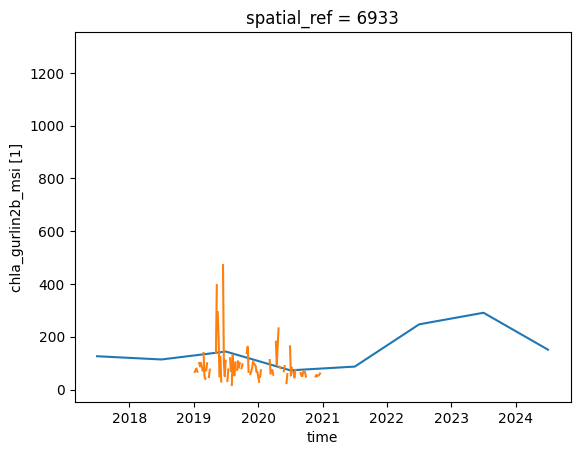

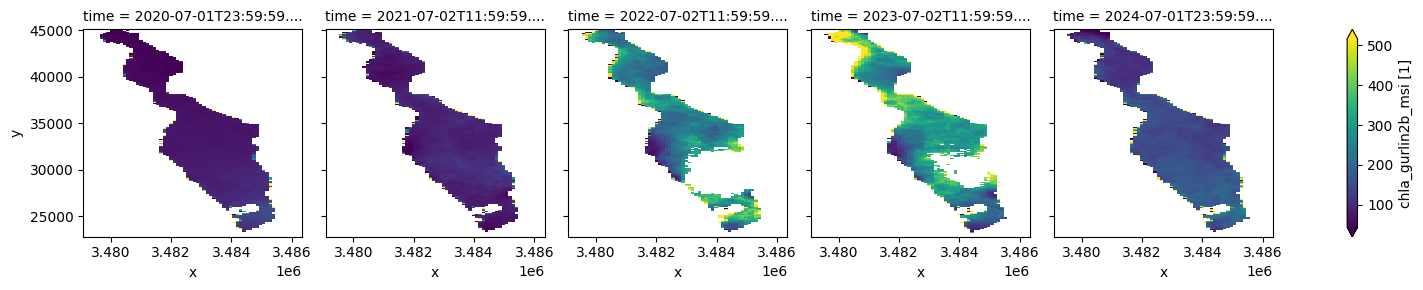

In [52]:
ds_annual.chla_gurlin2b_msi.median(dim=('x','y')).plot()
ds.chla_gurlin2b_msi.median(dim=('x','y')).plot()
plt.show()
ds_annual.chla_gurlin2b_msi.sel(time = slice('2020-01-01','2025-12-31')).plot(col='time',robust=True)

#### EXAMINE SOME RESULTS  - purely for visual checking purposes 
-   

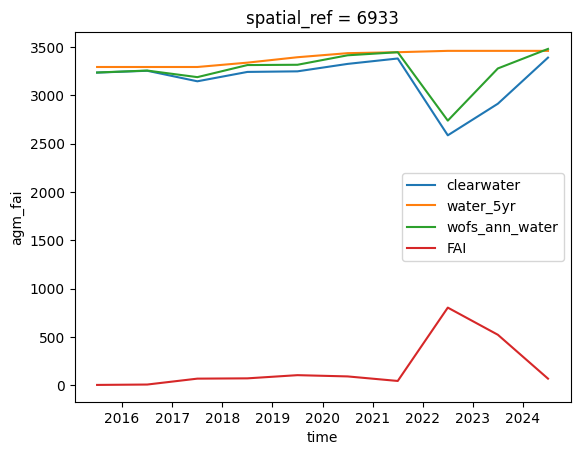

In [53]:
# this plot confirms that the water masks are behaving properly 
# which is vital to exclude non-target data resutls
ds_annual.where(ds_annual.clearwater==True).clearwater.count(dim=('x','y')).plot(label='clearwater')
ds_annual.where(ds_annual.water_5yr==True).water_5yr.count(dim=('x','y')).plot(label='water_5yr')
ds_annual.where(ds_annual.wofs_ann_water>0).wofs_ann_water.count(dim=('x','y')).plot(label='wofs_ann_water')
ds_annual.where(ds_annual.agm_fai>0).agm_fai.count(dim=('x','y')).plot(label='FAI')
plt.legend()
plt.show()

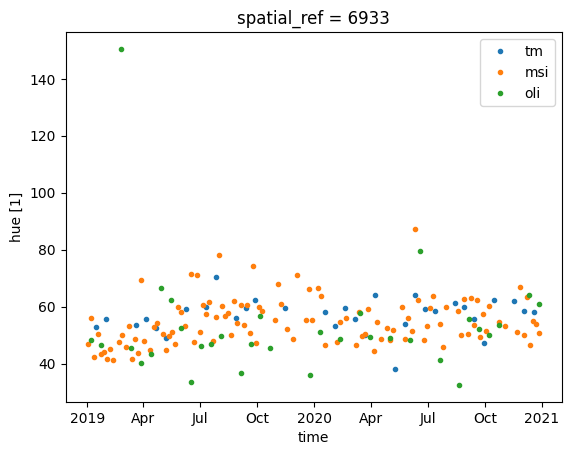

In [54]:
#ds.hue.loc[ds[instr] ==True].median(dim=('x','y')).plot()
for inst in 'tm','msi','oli':
    ds.where(ds.clearwater==True).hue.loc[ds[inst]==True].median(dim=('x','y')).\
        plot(label = inst,marker='.',linestyle='')
plt.legend()
plt.show()

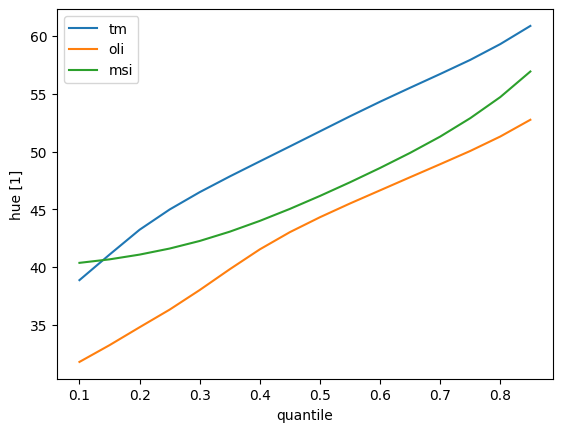

In [55]:
for inst in 'tm','oli','msi':
    ds.where(ds.water_5yr).where(ds[inst]==True).hue.quantile(np.arange(0.1,.90,0.05),dim=('x','y','time')).plot(label=inst)
plt.legend()
plt.show()

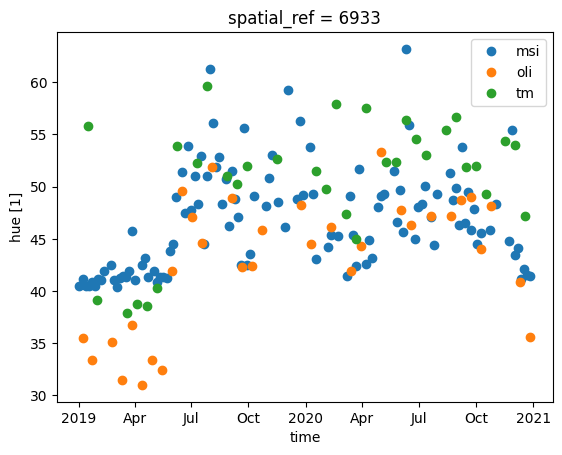

In [56]:
for inst in 'msi','oli','tm' :
    ds.where(ds.water_5yr).hue.loc[ds[inst]==True].median(dim=('x','y')).plot(linestyle='',marker='o',label=inst)
#ds.fai.loc[ds.tm==True].median(dim=('x','y')).plot(linestyle='',marker='d',label='tm')
plt.legend()
plt.show()

## A2 : Compile the results and choose a reference for each variable
- This is a 'manual' process 

In [11]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   

### Part A2 : Draw the results together and implement a harmonisation function 
- results data should be available for any sites with a Status of 100

### Read the log file to see which sites have been processed 
- results data should be available for any sites with a Status of 100

In [12]:
pd.read_csv('/home/jovyan/dev/deafrica_water_quality/WP2.2/parta_log.csv',index_col=0)

,PlaceName,Status,RunNumber,Year1,Year2
0,Haartbeesport_dam,100,0,0,0
1,HC_1,100,0,0,0
2,HC_2,100,0,0,0
3,HC_3,100,0,0,0
4,HC_4,100,0,0,0
5,HC_5,100,0,0,0
6,HC_6,100,0,0,0
7,Lake_Baringo,100,0,0,0
8,Senegal_StLouis,100,0,0,0
9,Lake_Sulunga,100,0,0,0


### Merge the results from all sites into a single results dataset 
- results data should be available for any sites with a Status of 100
- dataset dimensions are :
  - 'place' (one place for each site)
  - 'q' for quantile (q has values of 0, 0.01, .... 1.00), capturing the cumulative distribution of the variable
- dataset variables will be all the WQ variables
- **SAVE** this locally to '22A.nc'

In [331]:
# --- A function that reads results for a given  site
def read_statsfile(filename,pathname):
    suffix = '.nc'
    fname = pathname+filename+suffix 
    if os.path.exists(fname) :
        #print('opening '+fname)
        ds = xr.open_dataset(fname).load(); ds.close()
        #print('file found')
        return(ds)

In [332]:
# --- A function that reads all results files and merges to a single dataset of about 1MB in size
def merge_stats(log,filename,pathname,overwrite=True,verbose=True,test=False):
    suffix = '.nc'
    start = -1
    fname = pathname+filename+suffix 
    if not overwrite : 
        if os.path.exists(fname) :
            if test : print('existing file found',fname)
            dsr = read_statsfile(filename,pathname)
            start = 0
    for i in log.index.to_list() :
        placename = log.loc[i,'PlaceName']
        if verbose: print('Looking for '+placename)
        fname     = pathname+filename+'_'+placename+suffix
        if os.path.exists(fname) :
            if verbose: print('... found ')
            
            if  start < 0 :
                start = i
                dsr   = read_statsfile(filename+'_'+placename,pathname)
                if test: print(type(dsr))
            else :
                dsr=dsr.combine_first(read_statsfile(filename+'_'+placename,pathname))
    dsr.to_netcdf(pathname+filename+suffix)
    return(dsr)    

In [15]:
import os
if os.path.exists('test.csv'):
    print('hi')

hi


In [16]:
# --- wq_stats :
wq_stats

NameError: name 'wq_stats' is not defined

In [17]:
name = distributions_filename
distributions_unweighted_filename = name[0:name.find('.nc')]+'_unweighted'+'.nc'
distributions_unweighted_filename

'measurment_distributions_unweighted.nc'

In [ ]:
# ---- Merge distributions (from all the sample places) and write to .nc file
# ---------------------------------------------------------------------------------------------
a_log = pd.read_csv('/home/jovyan/dev/deafrica_water_quality/WP2.2/parta_log.csv',index_col=0)

wq_stats = merge_stats(a_log,parta_results_filename,results_directory)

#save in the work-package area:
wq_stats.to_netcdf(WP22+'wq_stats.nc')

# --- the overall distributions are calculated as the weighted mean of each quantile for the observed data ---
distributions = wq_stats.drop_dims('place')
distributions_unweighted = wq_stats.drop_dims('place')
for variable in wq_stats.data_vars:
    if 'q' in wq_stats[variable].sizes :
        distributions[variable] =  (wq_stats.loc[{'q':wq_stats.q[0:101]}][variable] * wq_stats.n).sum(dim='place') / wq_stats.n.sum()
        distributions_unweighted[variable] =  \
                                    (wq_stats.loc[{'q':wq_stats.q[0:101]}][variable]).mean(dim='place')

# ---- write the final distributions to a netcdf file in the data directory
#distributions.to_netcdf(data_directory+distributions_filename)

save_distributions_to_sourcecodearea = False
if save_distributions_to_sourcecodearea:
    distributions.to_netcdf(data_directory+distributions_filename)

#--- saving locally since code merge from development branch lost the other version
distributions.to_netcdf(WP22+distributions_filename)


# ---  not used, this is 'the same' data but calculated differently
name = distributions_filename
distributions_unweighted_filename = name[0:name.find('.nc')]+'_unweighted'+'.nc'
distributions_unweighted.to_netcdf(WP22+distributions_unweighted_filename)




In [ ]:
#plt.ylim(-10,10)
var = 'chla_3bda_'
for inst in ['oli','tm','msi']:
    distributions_unweighted[var+inst].plot(label=inst+' unweighted',linestyle=':')
    distributions[var+inst].plot(label=inst)
plt.ylim(-.1,.1)
plt.legend(loc='upper left')
plt.plot()


### Prove the harmonisation methods (i.e., effective adjustment of statistical distributions)
- Step 1: Quantiles from multiple sites are combined as a weighted mean
- Step 2: The merged distributions are matched
- Step 3: The results are plotted


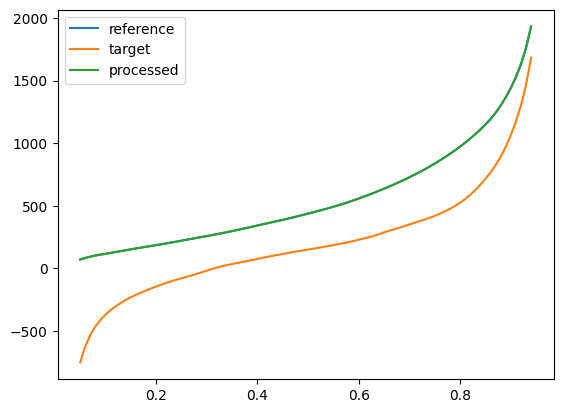

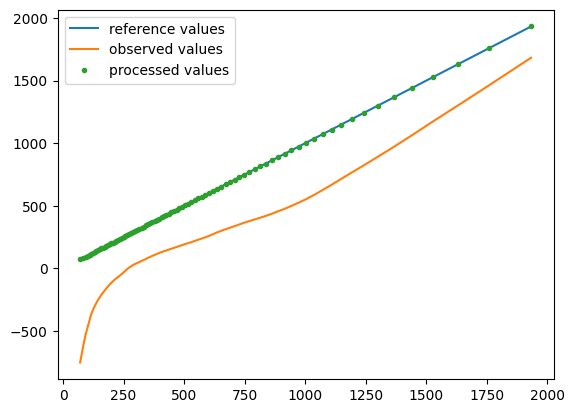

In [58]:
# Run the steps as described....

target  = 'chla_tebbs_oli'
reference = 'chla_tebbs_msi'
q0 = 5
q1 = 95

# Step 1 :Quantiles from multiple sites are combined as a weighted mean ---------------

target_dist_wm = ((wq_stats.loc[{'q':wq_stats.q[q0:q1]}][target] * wq_stats.n).sum(dim='place') / wq_stats.n.sum())
reference_dist_wm = ((wq_stats.loc[{'q':wq_stats.q[q0:q1]}][reference] * wq_stats.n).sum(dim='place') / wq_stats.n.sum())

target_dist    =  wq_stats.loc[{'q':wq_stats.q[q0:q1]}][target].mean(dim='place')
reference_dist =  wq_stats.loc[{'q':wq_stats.q[q0:q1]}][reference].mean(dim='place')
Q  = wq_stats.q[q0:q1]


# Step 2: The merged distributions are matched ---------

if True:
    method = 'quadratic'
    # --- fit a model to X; ie Q = f(x)
    f = sp.interpolate.interp1d(target_dist_wm,Q,kind=method,fill_value='extrapolate')
    # --- fit an inverse model to Y; ie Y = g(Q)
    g = sp.interpolate.interp1d(Q,reference_dist_wm,kind=method,fill_value='extrapolate')
    # --- new values are given by g(f(x)), which is very cool 

processed_dist = g(f(target_dist_wm))

# Step 3: the results are plotted -

plt.plot(Q,reference_dist_wm,label='reference')
plt.plot(Q,target_dist_wm,label='target')
plt.plot(Q,processed_dist,label='processed')
plt.legend()
plt.show()

plt.plot(reference_dist_wm,reference_dist_wm,label='reference values')
plt.plot(reference_dist_wm,target_dist_wm,label='observed values')
plt.plot(reference_dist_wm,processed_dist,label='processed values',linestyle='',marker='.')
plt.legend()
plt.show()




### Implement the harmonistaion method as a function
- A reference table that relates each variable to a reference variable
    - e.g. 'tsm_lym_oli' and 'tsm_lym_tm' would be referenced to 'tsm_lym_msi'
    - saved as the table called 'targ_ref_lookup.csv'

- A function to adjust the values of an input array
- Run the function

In [74]:
# ---- Build a lookup table for target and reference variables (once only)

# --- Specify the target-reference relationships here! ----
namearray  = np.array([
['ndci_msi54'      , 'ndci_msi74'],
['ndci_msi64'      , 'ndci_msi74'],   # the 64 mmt is very close to 74
['ndci_msi74'      , 'ndci_msi74'],  
['ndci_tm43'       , 'ndci_msi74'],
['ndci_oli54'      , 'ndci_msi74'],
['chla_gurlin2b_msi' , 'chla_gurlin2b_msi'],
['chla_toming_msi' , 'chla_toming_msi'],
['chla_3bda_msi'   , 'chla_3bda_msi'],
['chla_3bda_oli'   , 'chla_3bda_msi'],
['chla_3bda_tm'    , 'chla_3bda_msi'],
['chla_tebbs_msi'  , 'chla_tebbs_msi'],
['chla_tebbs_oli'  , 'chla_tebbs_msi'],
['chla_tebbs_tm'   , 'chla_tebbs_msi'],
['chla_meris2b_msi', 'chla_meris2b_msi'],
['chla_modis2b_msi', 'chla_modis2b_msi'],
['chla_modis2b_tm' , 'chla_modis2b_msi'],
['ndssi_rg_msi'    , 'ndssi_rg_msi'],
['ndssi_rg_oli'    , 'ndssi_rg_msi'],
['ndssi_rg_tm'     , 'ndssi_rg_msi'],
['ndssi_bnir_oli'  , 'ndssi_rg_msi'],    # this bnir_oli does not behave well; this will mitigate but we could leave it out altogether
['ti_yu_oli'       , 'ti_yu_oli'],
['ti_yu_tm'        , 'ti_yu_oli'],
['tsm_lym_oli'     , 'tsm_lym_msi'],
['tsm_lym_msi'     , 'tsm_lym_msi'],
['tsm_lym_tm'      , 'tsm_lym_msi'],
['tss_grb_msi'     , 'tss_grb_msi'],
['tss_grb_oli'     , 'tss_grb_msi'],
['tss_grb_tm'      , 'tss_grb_msi'],
['tss_gr_msi'      , 'tss_gr_msi'],
['tss_gr_oli'      , 'tss_gr_msi'],
['tss_gr_tm'       , 'tss_gr_msi'],
['spm_qiu_tm'      , 'spm_qiu_msi'],
['spm_qiu_msi'     , 'spm_qiu_msi'],
['fai_tm'          , 'fai_msi'],
['fai_oli'         , 'fai_msi'],
['fai_msi'         , 'fai_msi'],
['ndvi_tm'         , 'ndvi_tm'],
['ndvi_oli'        , 'ndvi_tm'],
['ndvi_msi'        , 'ndvi_tm'],
['hue_tm'          , 'hue_msi'],
['hue_oli'         , 'hue_msi'],
['hue_msi'         , 'hue_msi']])

# build a lookup table for target and reference variables
lookup = pd.DataFrame(columns= ['target','reference'],data = namearray)

# save the lookup table in the local directory:
lookup.to_csv('/home/jovyan/deafrica_water_quality/wq_results/'+lookup_table_filename)

lookup.to_csv('/home/jovyan/dev/deafrica_water_quality/WP2.2/'+lookup_table_filename)

In [75]:
# save the lookup table to the data directory
lookup.to_csv(data_directory+lookup_table_filename)

In [646]:
pd.read_csv(data_directory+'measurement_distributions.csv',index_col=0).head().to_csv('old_dists.csv')

In [652]:
distributions.to_dataframe().to_csv(data_directory+'measurement_distributions.csv')

## Checking .. distributions have changed slightly in a revision.. 

In [654]:
i = 0

/tmp/ipykernel_13531/310606983.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis.legend()


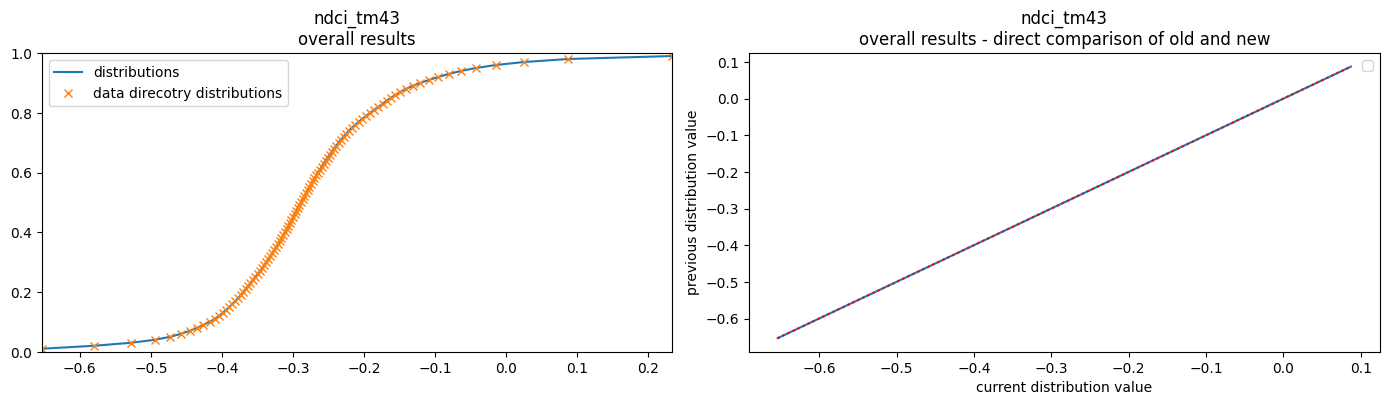

In [658]:
varname = 'chla_gurlin2b_msi'
varname = 'ndci_oli54'
varname = 'spm_qiu_msi'
varname = 'ndci_oli54'
varname = list(distributions.data_vars)[i]
i = i + 1
Q = np.arange(0,1.01,0.01)

fig, axes = plt.subplots(1,2,sharex=False, sharey=False, layout="constrained")    
fig.set_size_inches(35*cm,10*cm)

if False:
    axis = axes[0]
    axis.set_title(varname + '\nLake Bogoria results')
    axis.plot(ds[varname].quantile(Q),Q,label='dataset',linestyle='-',c='b')
    axis.plot(ds_annual[varname].quantile(Q),Q,label='geomedian',linestyle='-',c='k')
    axis.plot(read_dataset(results_directory+'22A_Lake Bogoria.nc')[varname].values.squeeze(),Q,label='stored dataset',linestyle='',marker='x')
    axis.plot(read_dataset(results_directory+'22A_Lake Bogoria_agm.nc')[varname].values.squeeze(),Q,label='stored geomedian',linestyle='',marker='x')
    #axis.plot(ds_annual[varname].quantile(Q),Q,label='annual geomedian')
    low,high = ds[varname].quantile((0.01,0.9))
    glow,ghigh = ds_annual[varname].quantile((0.01,0.9))
    
    axis.set_xlim(min(low,glow),max(high,ghigh))
    axis.set_ylim(0,1)
    axis.legend()

axis = axes[0]


axis.plot(distributions[varname].values.squeeze(),Q,label='distributions',linestyle='-',marker='')
axis.plot((pd.read_csv(data_directory+'measurement_distributions.csv'))[varname],Q,label='data direcotry distributions',linestyle='',marker='x')

low,high = distributions[varname].quantile((0.01,0.99))
axis.set_title(varname + '\noverall results')
axis.set_xlim(low,high)
axis.set_ylim(0,1)
axis.legend()

axis = axes[1]

x = distributions[varname].values.squeeze()
y = pd.read_csv(data_directory+'measurement_distributions.csv')[varname]
plt.plot(x[1:99],y[1:99])
plt.plot(x[1:99],x[1:99],linestyle=':',c='r')


axis.scatter(x[1:99],y[1:99],       label='',linestyle='-.',marker='')

axis.set_title(varname + '\noverall results - direct comparison of old and new')
axis.set_xlabel('current distribution value')
axis.set_ylabel('previous distribution value')


axis.legend()


plt.show()



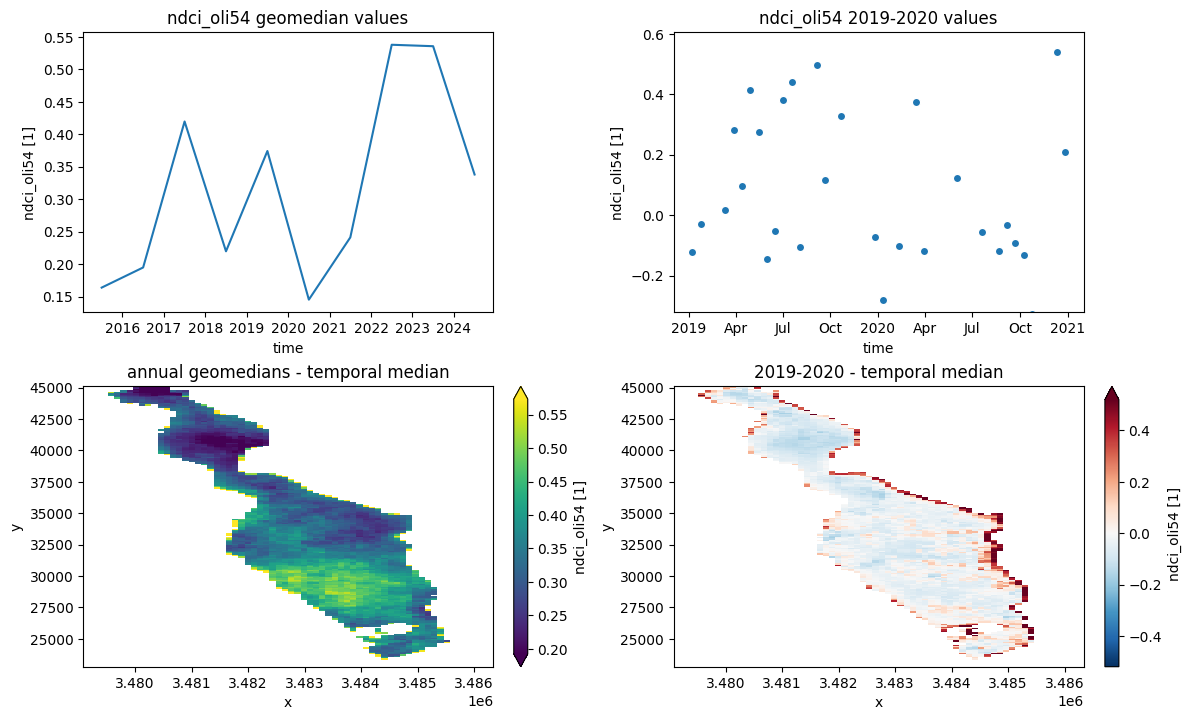

In [291]:
varname = 'chla_gurlin2b_msi'
varname = 'spm_qiu_msi'
varname = 'ndci_oli54'

cm = 1/2.54
fig, axes = plt.subplots(2,2,sharex=False, sharey=False, layout="constrained")    
fig.set_size_inches(30*cm,18*cm)

axis = axes[0,0]
ds_annual[varname].median(dim=('x','y')).plot(ax=axis)
axis.set_title(varname+ ' geomedian values')

axis = axes[0,1]
low,high = ds[varname].quantile((0.1,0.9))
axis.set_ylim(low,high)
ds[varname].median(dim=('x','y')).plot.scatter(ax=axis)
axis.set_title(varname + ' 2019-2020 values')

axis = axes[1,0]
ds_annual[varname].sel(time='2024').plot(robust=True,ax=axis)
axis.set_title('annual geomedians - temporal median')

axis = axes[1,1]
ds[varname].median(dim='time').plot(robust=True,ax=axis)
axis.set_title('2019-2020 - temporal median')

plt.show()

In [14]:
# The function is now elsewhere
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [25]:
g

In [59]:
# --- run the function, first reading the lookup table and the distributions data from files

#preliminary steps, read the lookup table and the disttibutions data - from the source data directory
lookup        = pd.read_csv(data_directory+lookup_table_filename,index_col=0)
distributions = xr.open_dataset(WP22+distributions_filename).load(); distributions.close()

example = harmonise_for_instrument(ds.hue.loc[ds.tm==True],'hue_msi',lookup,distributions)

#### Check some statistical and spatial outputs


variable name =  hue


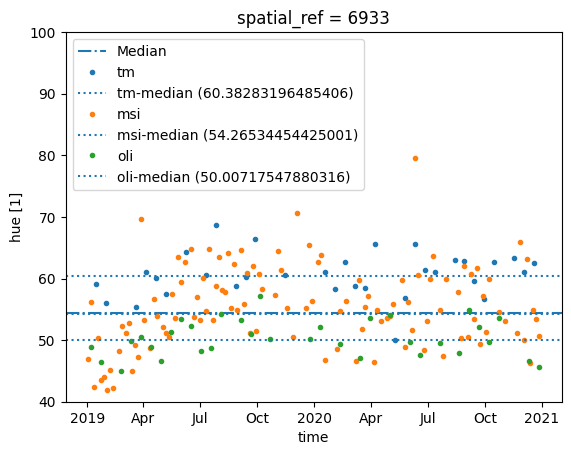

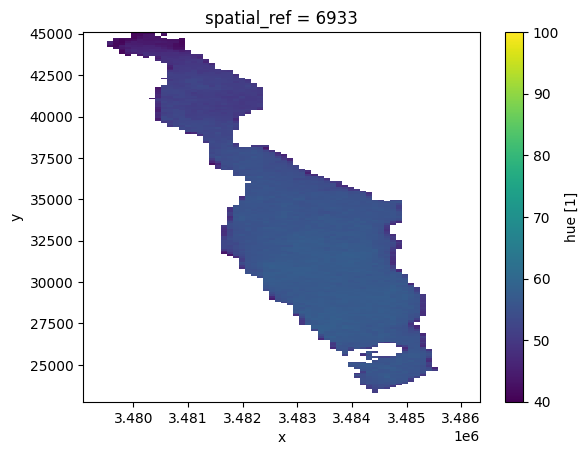

In [61]:
# before
#ds.hue.loc[ds[instr] ==True].median(dim=('x','y')).plot()
itemnumber = 0
params = [['hue',40,100],['ndvi',0,.6],['fai',0,.5]][itemnumber]
name,y0,y1   = params[0:3]
print('variable name = ',name)

plt.axhline(ds[name].where(ds.water_5yr==True).median(),linestyle='-.',label= str('Median'))
for inst in 'tm','msi','oli':
    #ds.where(ds.water_5yr==True)[name].loc[ds[inst]==True].median(dim=('x','y')).plot(label = inst,marker='.',linestyle='')
    ds.where(ds.water_5yr==True)[name].where(ds[inst]==True).median(dim=('x','y')).plot(label = inst,marker='.',linestyle='')
    median_value = ds.where(ds.water_5yr==True)[name].where(ds[inst]==True).median(dim=('x','y','time')) 
    l = str(inst+'-median ('+ str(median_value.item()) +')')
    plt.axhline(median_value,linestyle=':',label=l)
    
plt.ylim(y0,y1)
plt.legend()
plt.show()
ds.where(ds.water_5yr==True)[name].median(dim='time').plot(vmin=y0,vmax=y1)

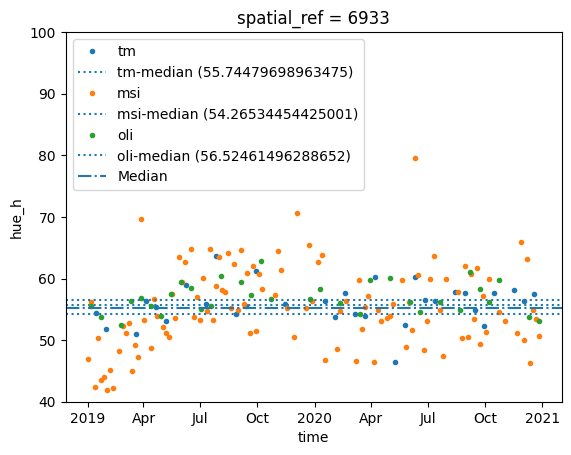

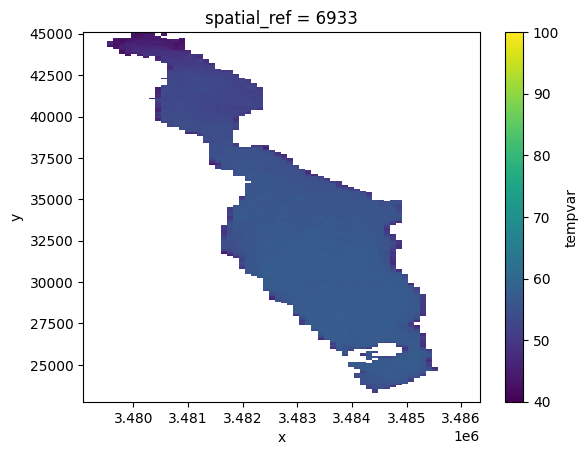

In [62]:
# After
#ds.hue.loc[ds[instr] ==True].median(dim=('x','y')).plot()
ds['tempvar'] = ds[name] * np.nan
for inst in 'tm','msi','oli':
    new = harmonise_for_instrument(
        #ds.where(ds.clearwater==True).hue.loc[ds[inst]==True],
        ds.where(ds.water_5yr==True)[name].where(ds[inst]==True),
        name+'_'+inst,
        lookup,distributions)
    new.median(dim=('x','y')).\
        plot(label = inst,marker='.',linestyle='')
    median_value = new.median(dim=('x','y','time')) 
    plt.axhline(median_value,linestyle=':',label= str(inst+'-median ('+ str(median_value.item()) +')')
    )
    ds['tempvar'] = xr.where(ds[inst]==True,new,ds.tempvar)
plt.axhline(ds['tempvar'].median(),linestyle='-.',label= str('Median'))

plt.ylim(y0,y1)
plt.legend()
plt.show()
ds.where(ds.water_5yr==True).tempvar.median(dim='time').plot(vmin=y0,vmax=y1)


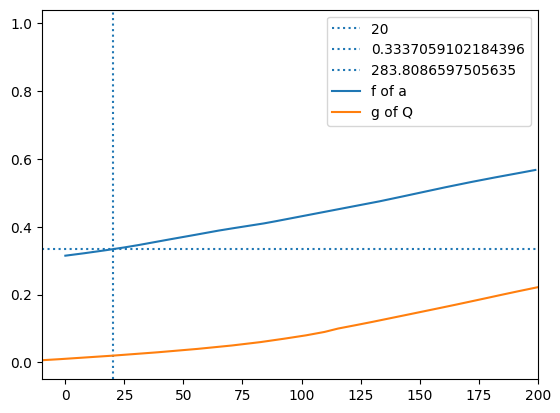

In [63]:
x = 20
qx = f(x)
gqx = g(qx)
plt.axvline(x,linestyle=':',label=x)
plt.axhline(qx,linestyle=':',label=qx)
plt.axvline(gqx,linestyle=':',label=gqx)
a = np.arange(0,200)
plt.plot(a,f(a),label='f of a')
b = np.arange(0,1,0.01)
plt.plot(g(b),b,label='g of Q')
plt.xlim(-10,200)
plt.legend()
plt.show()

tsm_lym_tm tsm_lym_msi


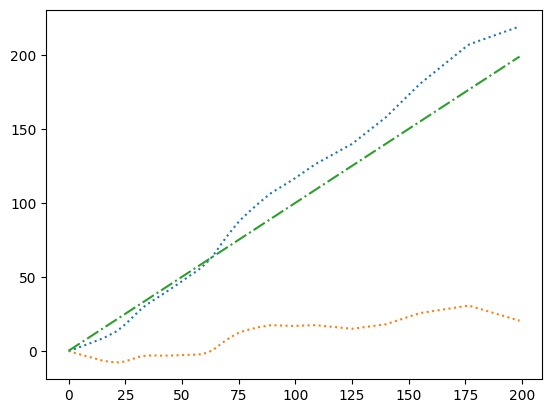

In [516]:
a = xr.DataArray(dims='dummy',data=np.arange(0,200,1),name='test')
b,f,g = harmonise_for_instrument(a,'tsm_lym_tm',lookup,distributions)
plt.plot(a,b,linestyle=':')
plt.plot(a,g(f(a))-a,linestyle=':')
plt.plot(a,a,linestyle='-.')


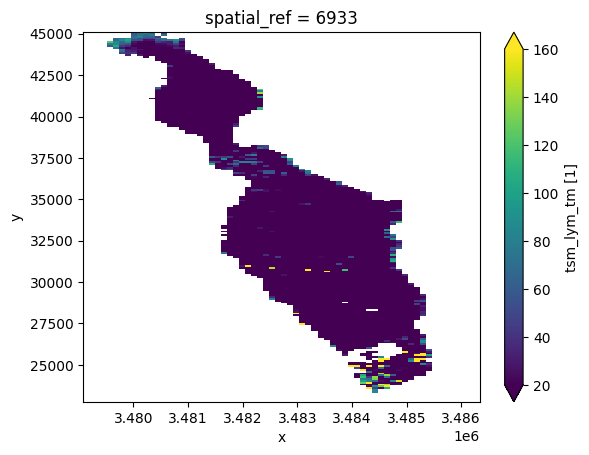

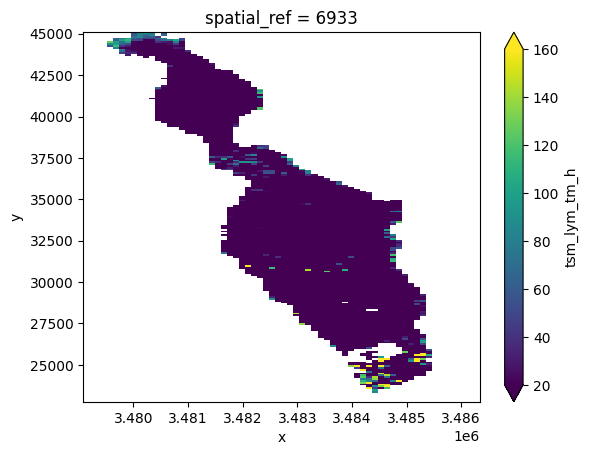

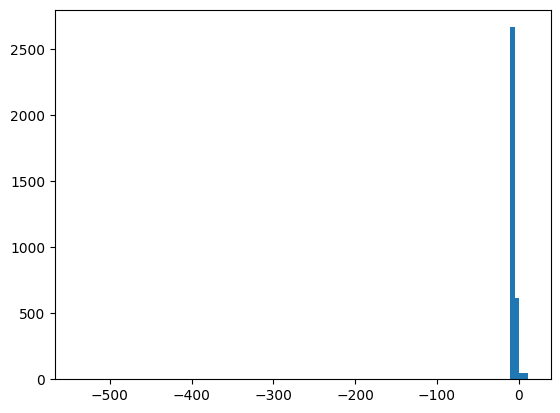

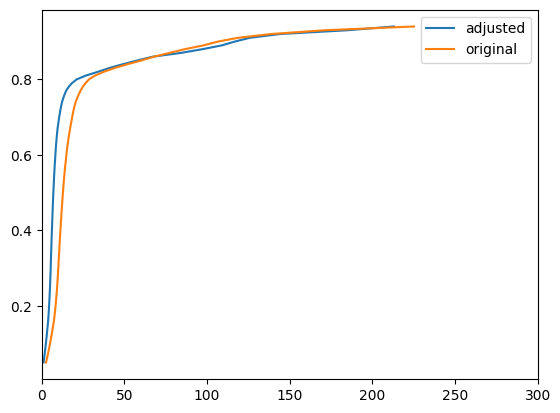

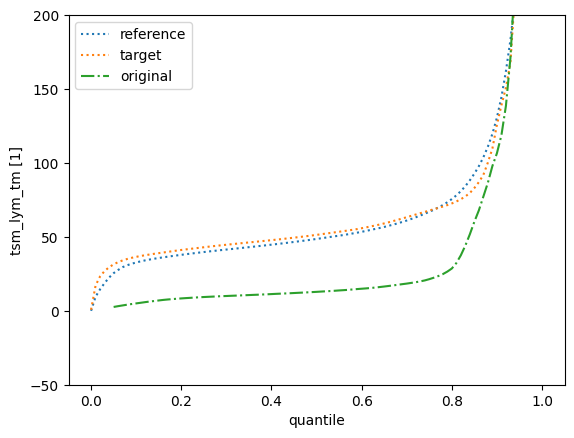

In [66]:
inst = 'tm'
name='tsm_lym'
var = name + '_' + inst
ds.where(ds.clearwater==True)[var].median(dim=('time')).plot(vmin=20,vmax=160); plt.show()

ds[var+'_h'] = harmonise_for_instrument(
        #ds.where(ds.clearwater==True).hue.loc[ds[inst]==True],
        ds.where(ds.clearwater==True)[var],
        var,
        lookup,distributions)

ds[var+'_h'].median(dim=('time')).plot(vmin=20,vmax=160); plt.show()

plt.hist(
    ((ds[var+'_h'].median(dim=('time')) - \
     ds.where(ds.clearwater==True)[var].median(dim=('time'))).values.flatten()) \
,bins=100); 

plt.show()


plt.plot(ds[var+'_h'].quantile(Q),Q,label='adjusted')
plt.plot(ds[var]     .quantile(Q),Q,label='original')
plt.xlim(0,300)
plt.legend()
plt.show()
plt.plot(distributions.q,distributions[lookup[lookup.target==var].reference.item()],label='reference',linestyle=':')
plt.plot(distributions.q,distributions[lookup[lookup.target==var].target.item()],label='target',linestyle=':')
ds.where(ds.clearwater==True)[var].quantile(Q).plot(linestyle ='-.',label = 'original')
plt.ylim(-50,200)
plt.legend()
plt.show()

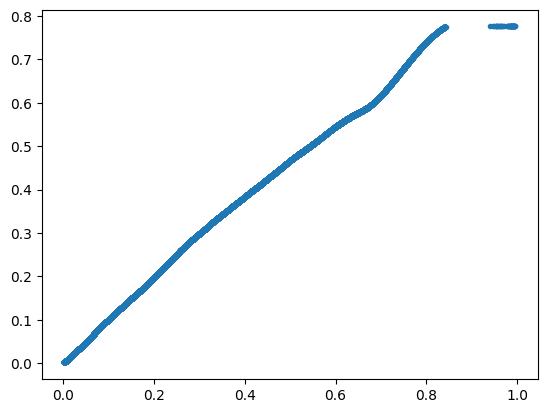

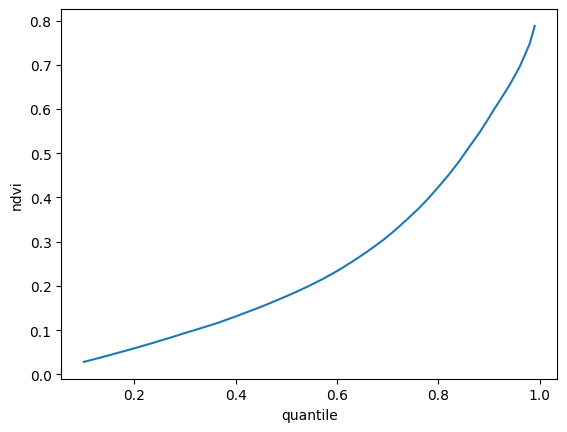

In [269]:
plt.scatter(ds[name].where(ds[inst]==True).where(ds.water_5yr==True),ds[name+'_'+inst+'_h'],marker='.')
plt.show()
ds[name].where(ds[inst]==True).where(ds.water_5yr==True).quantile(np.arange(0.1,1,0.01)).plot()
#plt.scatter(ds[name].where(ds[inst]==True).where(ds.water_5yr==True),ds[name].where(ds[inst]==True).where(ds.water_5yr==True))


In [570]:
ds_annual.data_vars

Data variables:
    oli05_agm            (time, y, x) float64 1MB 1.677e+03 ... 2.268e+03
    oli06_agm            (time, y, x) float64 1MB 1.95e+03 ... 1.221e+03
    oli07_agm            (time, y, x) float64 1MB 1.514e+03 1.61e+03 ... 607.0
    oli_agm_smad         (time, y, x) float32 536kB 0.0007695 ... 0.003295
    oli_agm_emad         (time, y, x) float32 536kB 183.0 178.0 ... 435.0 458.0
    oli_agm_bcmad        (time, y, x) float32 536kB 0.02677 0.02538 ... 0.06547
    oli_agm_count        (time, y, x) float64 1MB 15.0 15.0 16.0 ... 29.0 28.0
    msi8a_agm            (time, y, x) float32 536kB nan nan ... 2.958e+03
    msi11_agm            (time, y, x) float32 536kB nan nan ... 1.685e+03
    msi12_agm            (time, y, x) float32 536kB nan nan nan ... 951.0 912.0
    msi_agm_smad         (time, y, x) float32 536kB nan nan ... 0.00178 0.002002
    msi_agm_emad         (time, y, x) float32 536kB nan nan nan ... 568.8 744.2
    msi_agm_bcmad        (time, y, x) float32 536kB nan

(0.0, 30000.0)

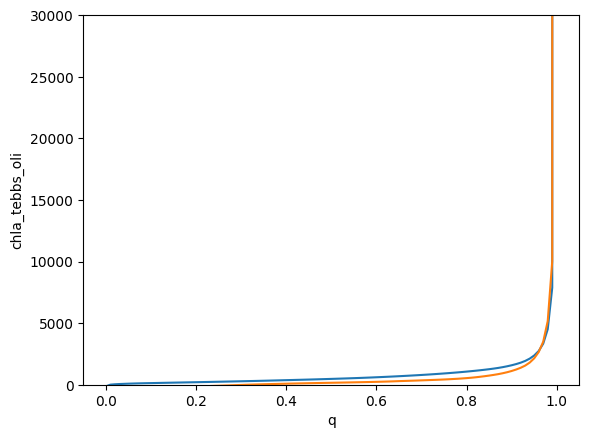

In [637]:
distributions.chla_tebbs_msi.plot()
distributions.chla_tebbs_oli.plot()
plt.ylim(0,30000)

In [624]:
# The function is now elsewhere
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [26]:
# Apply the function to a variable from the annual dataset...
mmt = 'chla_3bda'
mmt = 'fai'
inst = 'oli'
var = mmt+'_'+inst
ref = mmt+'_'+'msi'
ds_annual[var].mean(dim='time').plot(); plt.show()
harmonise_for_instrument(ds_annual[var],
        var,
        lookup,distributions,test=False).mean(dim='time').plot(); plt.show()

NameError: name 'ds_annual' is not defined

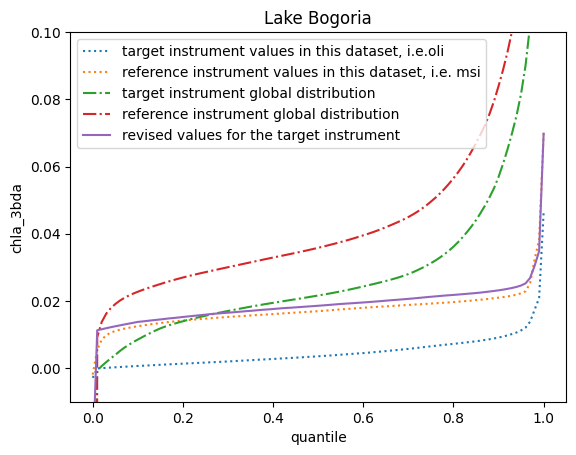

In [671]:
plt.plot(distributions.q,ds_annual[var].quantile(distributions.q),linestyle=':',label='target instrument values in this dataset, i.e.'+inst)
plt.plot(distributions.q,ds_annual[ref].quantile(distributions.q),linestyle=':',label='reference instrument values in this dataset, i.e. msi')
plt.plot(distributions.q,distributions[var],linestyle='-.',label='target instrument global distribution')
plt.plot(distributions.q,distributions[ref],linestyle='-.',label='reference instrument global distribution')
plt.plot(distributions.q,
         (harmonise_for_instrument(ds_annual[var],var,lookup,distributions,test=False)).quantile(distributions.q),linestyle='-',label='revised values for the target instrument')
plt.ylim(-0.01,.1)
plt.title('Lake Bogoria')
plt.ylabel(mmt)
plt.xlabel('quantile')
plt.legend()
plt.show()

In [686]:
a_log

,Unnamed: 0,PlaceName,Status,RunNumber,Year1,Year2
0,0,Haartbeesport_dam,100,0,0,0
1,1,HC_1,100,0,0,0
2,2,HC_2,100,0,0,0
3,3,HC_3,100,0,0,0
4,4,HC_4,100,0,0,0
5,5,HC_5,100,0,0,0
6,6,HC_6,100,0,0,0
7,7,Lake_Baringo,100,0,0,0
8,8,Senegal_StLouis,100,0,0,0
9,9,Lake_Sulunga,100,0,0,0


### Visualisations used to examine the distributions and choose the reference variable in each case
- The MSI instrument is generally used as the reference instrument.

MSI:
- produces the most data, and;
- generally produces the distributions which have fewest extremes, and;
- produces data with high variance through normal values (variance indicates potential to differentiate) .


##### Look at results for a specific site(s):

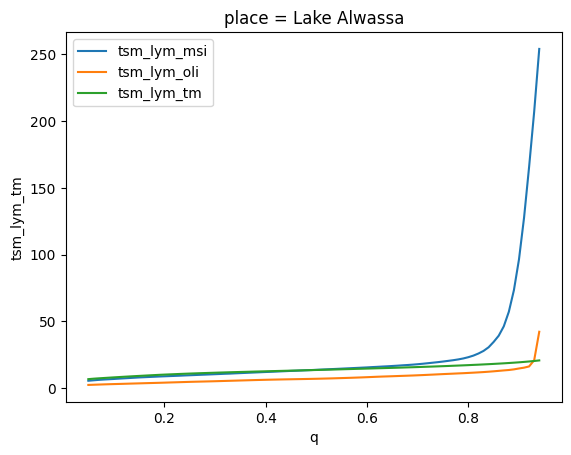

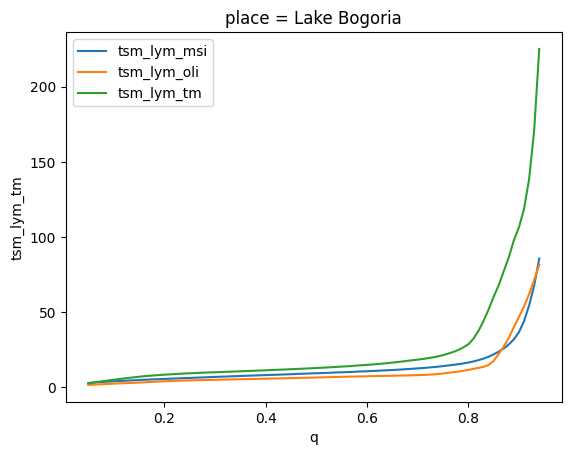

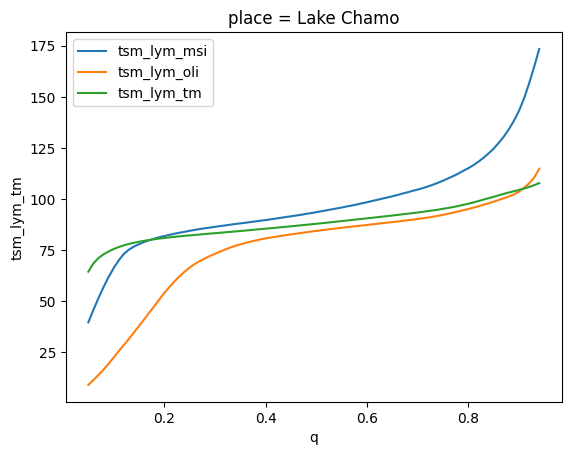

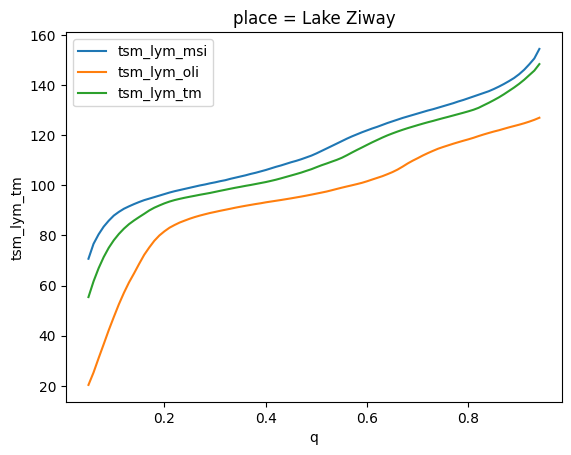

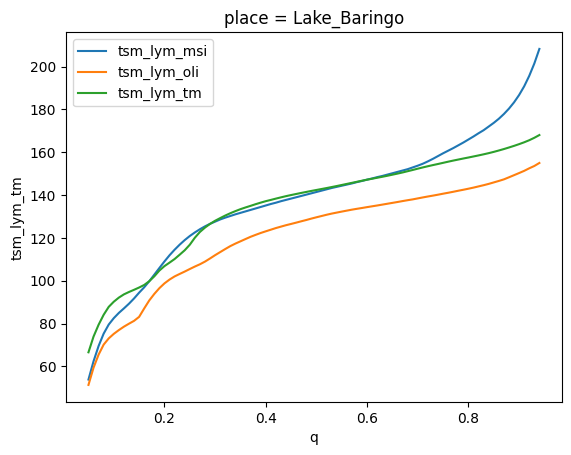

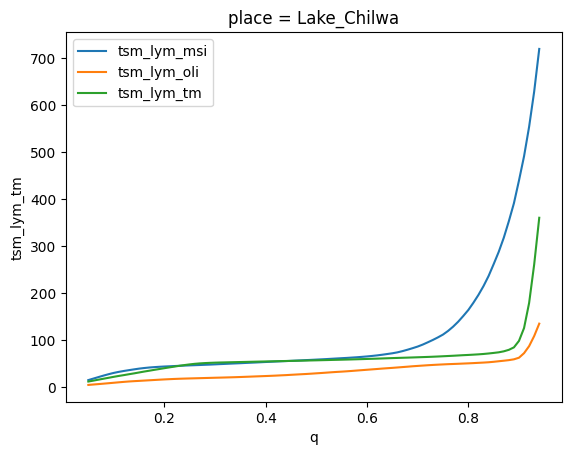

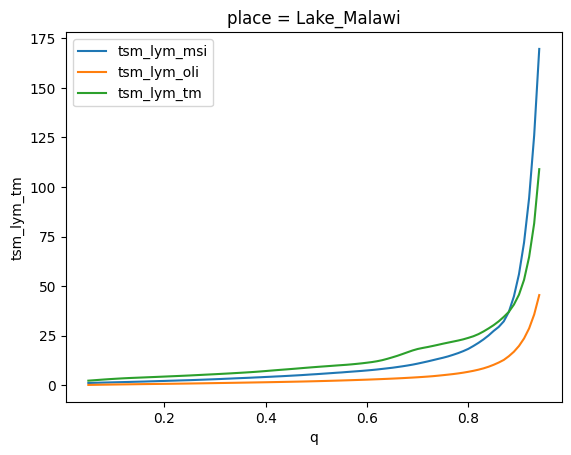

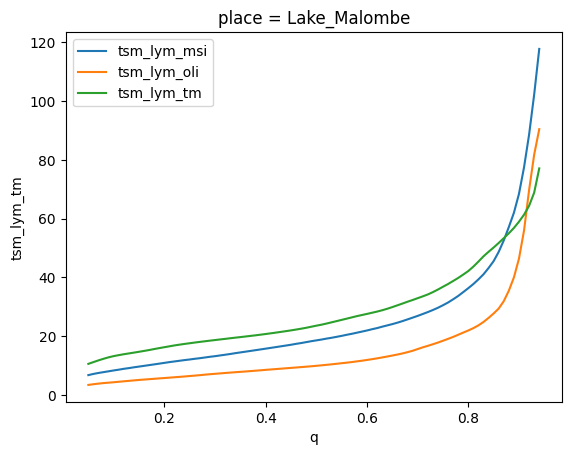

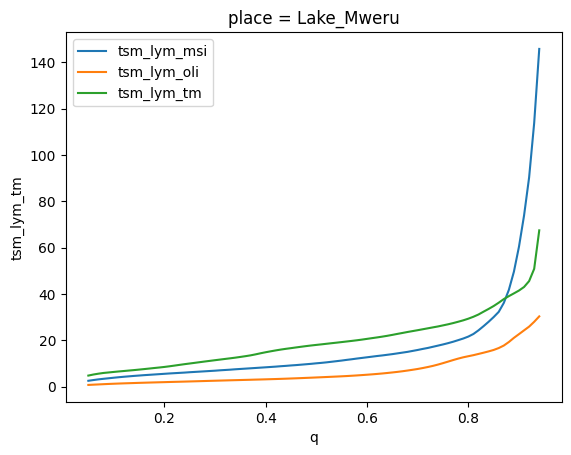

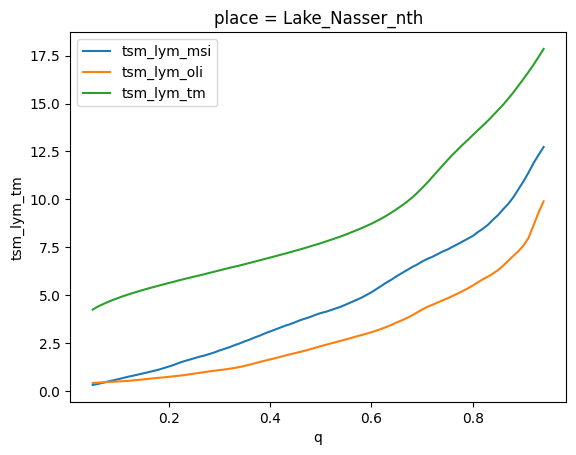

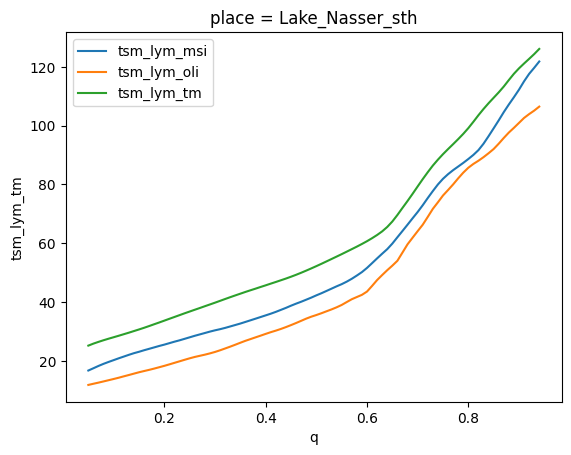

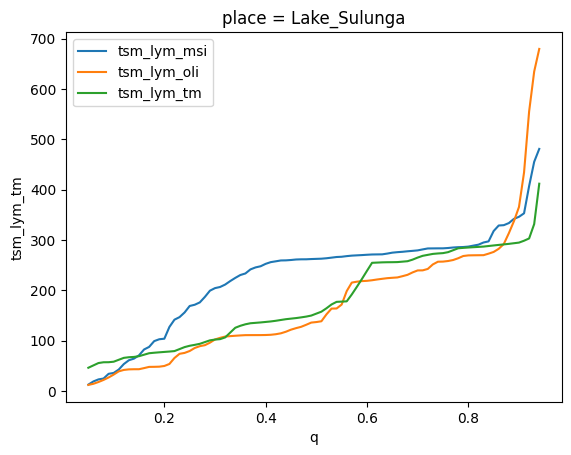

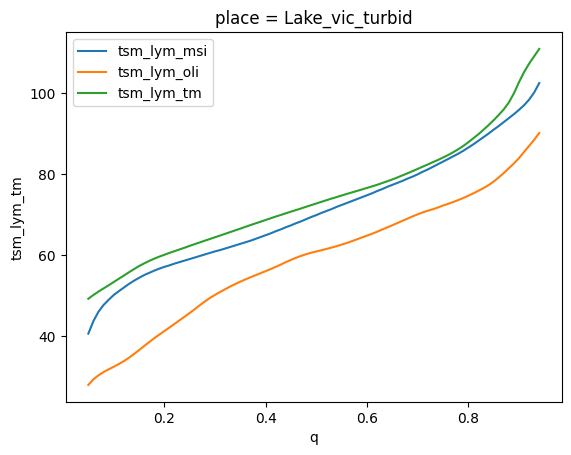

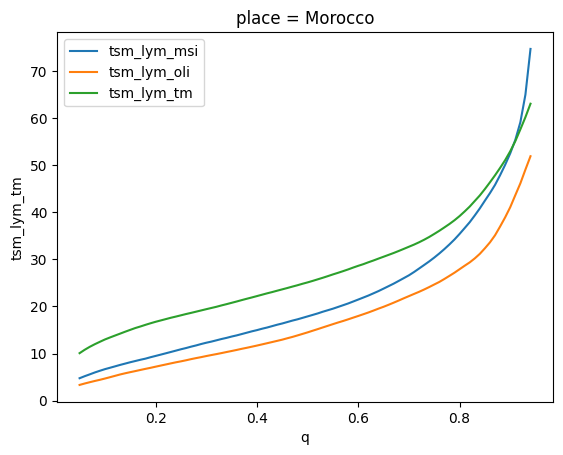

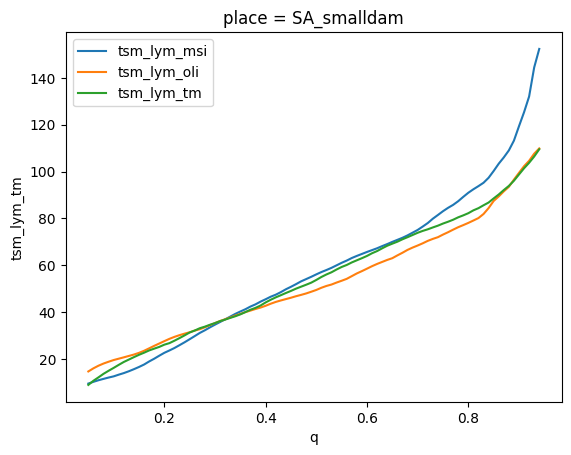

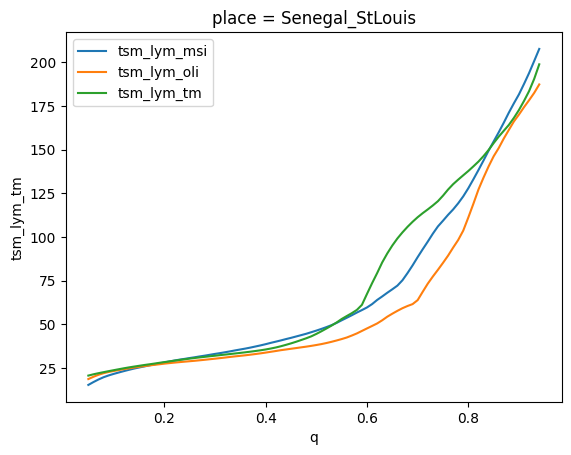

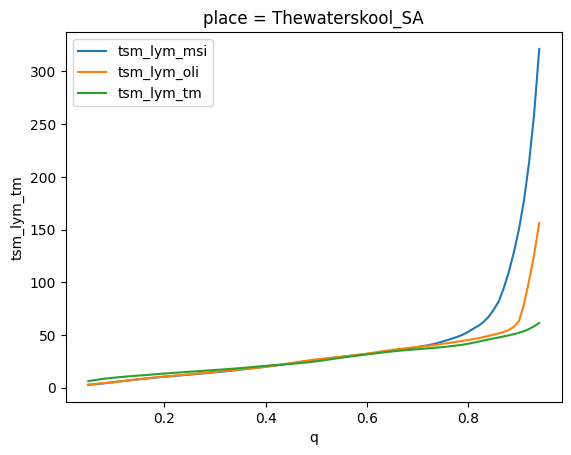

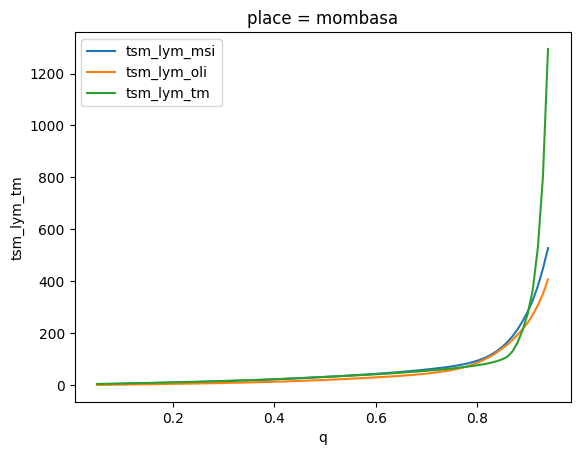

In [67]:
# --- display results for some sites and variables
placename = 'Haartbeesport_dam'
placename = 'HC_1'
placename = 'HC_2'
placename = 'HC_3'
placename = 'HC_4'
placename = 'HC_5'
placename = 'HC_6'
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
parta_results_filename   = '22A'
pathname = results_directory
filename = parta_results_filename+'_'+placename

dsr = read_statsfile(filename,pathname)

# selecting the reference distribution for the ndci variables..

for i in np.arange(12,wq_stats.place.size):
    placename = wq_stats.place[i]
    for instr in ['tsm_lym_msi'  , 'tsm_lym_oli', 'tsm_lym_tm'] :
        wq_stats.loc[{'place':placename,'q':wq_stats.q[5:95]}][instr].plot(label=instr)
    plt.legend()
    plt.show()
#conclude that msi54 is the best distribution for haarteesport dam

##### Look at results across all sites:

['tsm_lym']


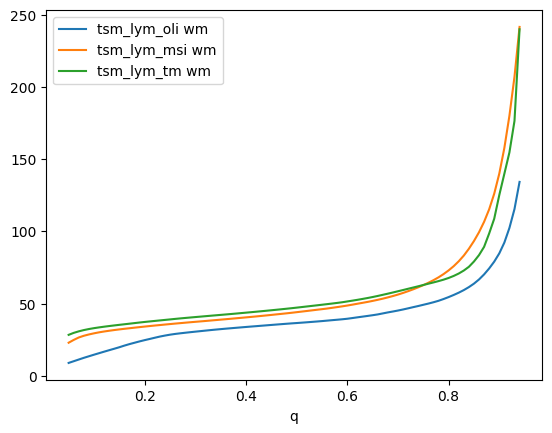

In [406]:
# --- visualise results for selected variables across all test sites...

mmt={}
mmt['ndci']         = ['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43','ndci_oli54']
mmt['chla_toming']  = ['chla_toming_msi']
mmt['chla_3bda']    = ['chla_3bda_msi', 'chla_3bda_oli','chla_3bda_tm']
mmt['chla_tebbs']   = ['chla_tebbs_msi', 'chla_tebbs_oli','chla_tebbs_tm']
mmt['chla_meris2b'] = ['chla_meris2b_msi', 'chla_modis2b_msi','chla_modis2b_tm']
mmt['ndssi_rg']     = ['ndssi_rg_msi'  , 'ndssi_rg_oli', 'ndssi_rg_tm', 'ndssi_bnir_oli']
mmt['ti_yu']        = ['ti_yu_oli', 'ti_yu_tm']
mmt['tsm_lym']      = ['tsm_lym_oli','tsm_lym_msi','tsm_lym_tm']
mmt['tss_grb'] = ['tss_grb_msi', 'tss_grb_oli','tss_grb_tm']
mmt['tss_gr']  = ['tss_gr_msi', 'tss_gr_oli', 'tss_gr_tm']
mmt['spm_qiu'] = ['spm_qiu_tm', 'spm_qiu_msi']
mmt['fai']     = ['fai_tm', 'fai_oli', 'fai_msi']
mmt['ndvi']    = ['ndvi_tm', 'ndvi_oli', 'ndvi_msi']
mmt['hue']     = ['hue_tm', 'hue_oli', 'hue_msi']

measurements = list(mmt.keys())
measurements = ['ndci']
i = 0

q0 = 5
q1 = 95
measurements = [list(mmt.keys())[i]]
print(measurements)
for m in list(measurements):
    for variable in mmt[m]:
#        wq_stats.loc[{'q':wq_stats.q[q0:q1]}][variable].mean(dim='place').plot(label=variable)
        ((wq_stats.loc[{'q':wq_stats.q[q0:q1]}][variable] * wq_stats.n).sum(dim='place') / wq_stats.n.sum()).plot(label=variable+' wm',linestyle='-',marker='')
                                                                                                                  

    plt.legend()
    plt.show()
i += 1
#conclude that msi54 is the best distribution for haarteesport dam

# Part B, Measurement to Measurement Harmonisation

In [1]:
# The function is now elsewhere
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py


In [7]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [2]:
# --- operating parameters and dictionary of places ---


In [4]:
# --- controlling parameters and settings
verbose = True
test    = False
max_cells = 100000   #use this to test memory limits. Memory saving steps are going to be needed...
max_cells = 5000   #use this to test memory limits. Memory saving steps are going to be needed... (Results are not particularly sensitive to cell size)


In [5]:
# --- set which instruments to use (this is checked later against the date range for each place)
# --- for Phase1, mapping, the main datasets are the geomedians. For monioring the local time-seres will be brought in as well as the geomedians.
# --- temperature is yet to be included.

instruments_to_use = {
    'oli_agm'  : {'use': True },
    'oli'      : {'use': False},
    'msi_agm'  : {'use': True },
    'msi'      : {'use': False},
    'tm_agm'   : {'use': True },
    'tm'       : {'use': False},
    'tirs'     : {'use': False},  
    'wofs_ann' : {'use': True },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

year1 = '2000'
year2 = '2024'
# --- don't try to use instruments for which there are no data 
instruments_to_use = check_instrument_dates(instruments_to_use,int(year1),int(year2),verbose=False)

# --- retain a dictionary of the instruments and measurements that are on-hand ---
instruments    = instruments_list(instruments_to_use)[0]  # a list of the instruments  in use
            
# --- get the dictionary of all possible places for analysis ---
places_dict     = set_spacetime_domain()   

In [8]:
# --- start the log file and parameters dictionary --- 

logfilename = 'log.csv'
log = open_logfile(places_dict,logfilename,overwrite='Append')
log.head()

appending


,PlaceName,Status,RunNumber,Year1,Year2,x0,x1,y0,y1,t0,t1,CellArea,Resampling
0,Lake_Baringo,100,0,2000,2024,36.0000,36.1700,0.450,0.7400,2000,2024,0.0484,nearest
1,Lake_Tikpan,100,0,2000,2024,1.8215,1.8265,6.459,6.4626,2000,2024,0.0001,bilinear
2,Lake_Chad,100,0,2000,2024,12.9700,15.5000,12.400,14.5000,2000,2024,1.0000,nearest
3,Weija_Reservoir,100,0,2000,2024,-0.3250,-0.4100,5.540,5.6200,2000,2024,0.0064,nearest
4,Senegal_StLouis,100,0,2000,2024,-15.7400,-15.8400,16.300,16.3900,2000,2024,0.0081,nearest


## B-1 Run the geomedian analysis for all target sites
- the process runs only for those sites in the log file that have status < 100
- the results for each waterbody / target area are saved as a netcdf file
- in part B-2 these files are read back in for comparison

In [677]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [670]:
# re-set to zero sites that are to be re-processed
log.loc[:,'Status'] = 0

In [ ]:
# --- run the process for all places in the log file...
logfilename = 'log.csv'  # just to be sure! 
over_write = True # to overwrite previous results
verbose    = False
for placename in places_dict.keys():
    if places_dict[placename]['run'] == True:
        if log.loc[log.PlaceName==placename,'Status'].item() < 100 :
            print(placename)
            results_filename = all_results_filename+'_'+placename+'.nc'
            spacetime_domain, grid_resolution, cell_area, resampling_option, year1, year2 \
                           = set_spacetime_domain(placename,year1,year2,max_cells,verbose,False)
            parameters = store_parameters(placename,
                                          spacetime_domain,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1,
                                          year2)
            i = 1 
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                log = log_parameters(log,placename,parameters)
            # check to see if the outputs already exist and if so reset the status value
            if os.path.exists(results_directory+results_filename) : 
                if not over_write :
                    log = log_update(log,placename,100,logfilename)
            i+=1 
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds             = build_agm_dataset(parameters,instruments_to_use,verbose = verbose)
                log = log_update(log,placename,i,logfilename)        
            i+=1 
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds_annual = detect_geomedian_instruments(ds_annual)
                log     = log_update(log,placename,i,logfilename,logfilename)
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds  = calculate_agm_count(ds)
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                # --- controling parameters for water mapping on a pixel by pixel basis ---
                WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
                PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
                SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
                ds   = water_analysis(ds,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = test)
                ds              = WOFS_5_year_frequency(ds,False)
                ds['water_5yr'] = xr.where(ds.wofs_5yr_freq>0.45,ds.wofs_5yr_freq.astype('bool'),np.nan)
                ds              = detect_geomedian_instruments(ds)
                # results is a dictionary that contains the parameters and a dataframe of annual results
                results         = initiate_results_dictionary(ds,parameters)
                ds              = geomedian_FAI(ds,ds.water_5yr)
                ds              = set_clearwater(ds,'agm_fai','water_5yr','wofs_ann_water')
                log = log_update(log,placename,i,logfilename)        
            i+=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                ds              = apply_R_correction(ds,['msi_agm','oli_agm','tm_agm'],
                                                 water_mask=ds.water_5yr,drop = True, 
                                                 test = False,verbose=False)
                
                log = log_update(log,placename,i,logfilename)        
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
            
                ds = geomedian_hue(ds,ds.clearwater==True,test=True,verbose=True)
                ds = run_OWT(ds)
                log = log_update(log,placename,i,logfilename)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
                ds,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                        algorithms_tsm,  
                        instruments, 
                        new_dimension_name='tss_measure', 
                        new_varname='tss', 
                        verbose=verbose)
                ds,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                        algorithms_chla, 
                        instruments, 
                        new_dimension_name='chla_measure', 
                        new_varname='chla',
                        verbose=verbose)
                log = log_update(log,placename,i,logfilename)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                wq_results = calc_statistics(ds,placename)
                log = log_update(log,placename,i,logfilename)                      
            i +=1
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                
                save_results(wq_results,results_filename,results_directory)
                log = log_update(log,placename,i,logfilename)       
            if log.loc[log.PlaceName==placename,'Status'].item() <i:
                print(' this should not happen')
            else : 
                print('end of process for place = '+placename+'. Setting status to 100')
                log = log_update(log,placename,100,logfilename)       
                


## B-2 Read in results from an annual geomedian analysis
- the results from each waterbody / target area are read and merged to a single working dataset
- using the statistics from all the study areas, global adjustments are derived for each measurement to match a chosen reference
- the simplest form of those adjustments is a scale and shift. This is also very defensible since the underlying assumptions are minimal

In [780]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [739]:
WP22+distributions_filename

'/home/jovyan/dev/deafrica_water_quality/WP2.2/measurment_distributions.nc'

In [778]:
# open the reference data files produced in part A
distributions = read_dataset(WP22+distributions_filename)
lookup        = pd.read_csv(WP22+lookup_table_filename,index_col=0)

#### chla_meris2b_msi has the best statistical distribution
(based on the distributions derived from the 30 sites used in harmonisation and calibration):
- 1 percentile value is :  -3.14 (this is credibly close to zero)
- 50 percentile values is: 27.9  (this is the closest any variable gets to the median value of 20.88 +- 9 estimated by Zhou et al 2024.)

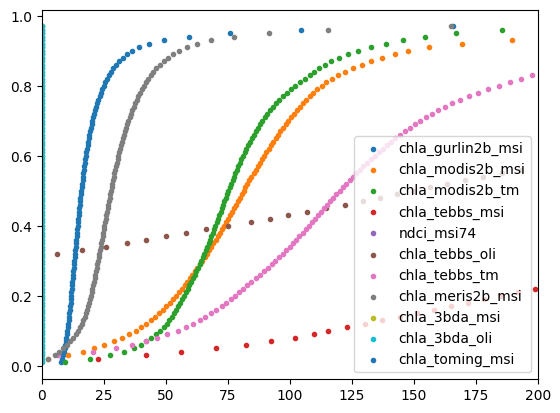

In [776]:
i,j  = 1,98
exclude_list = set(['ndci_msi64','ndci_tm43','ndci_msi54','ndci_oli54',
                    'chla_3bda_tm',''])
varlist = set(list(wq_results.chla_measure.values)) - exclude_list
plt.xlim(0,200)
for var in varlist:

    plt.scatter(distributions[var][i:j],distributions.q[i:j],marker='.',label=var)
plt.legend(loc='lower right')


#### Step 1., compile all the results to a single dataset

In [781]:
# --- merge the results file to a single dataset. 
# Note that writing a large file to netcdf and then readin back in loses information
# The place names get truncated for some reason. For that reason, I keep them all separate and merge
wq_results = merge_results(log,all_results_filename,results_directory)

#### Step 2., apply inter-instrument harmonisation process. 
##### For a given algorithm (e.g., ndci), 
- results from oli and tm are adjusted to be consistent with results from msi (ususally)
- NO CHANGE is made (in this step) if the algorithm was used with only one sensor.

In [782]:
# loop through tss and chla data arrays withing the dataset...
# loop through the variables in each case... 
# assign values  back into the dataset
for mmt in 'tss','chla':
#    data  = wq_results[mmt]
    vartype = mmt+'_measure'
    for varname in list(wq_results[vartype].values):
        wq_results[mmt].loc[{vartype :[varname]}]= \
            harmonise_for_instrument(
                wq_results[mmt].loc[{vartype :[varname]}],
                #data.loc[{vartype : varname}],
                varname,
                lookup,
                distributions,
                test=False)
#data.loc[{vartype : varname}] =\
#        data.loc[{vartype : varname}] = -1
#wq_results[mmt] = data

In [ ]:
wq_results

#### Step 3, calculate the scale and offset to adjust each mmt to a reference variable 

In [784]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

In [872]:
wq_results = calc_scale_and_offset(wq_results,verbose=False)
wq_results.time[13:17]

<xarray.DataArray 'time' (time: 4)> Size: 32B
array(['2013-07-02T11:59:59.999999000', '2014-07-02T11:59:59.999999000',
       '2015-07-02T11:59:59.999999000', '2016-07-01T23:59:59.999999000'],
      dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 32B 2013-07-02T11:59:59.999999 ... 201...
    spatial_ref  int32 4B 6933

#### Step 4, apply a scale factor for tm-era to msi-era
- the time periods of 2000-2012, 2013-2025, and 2017-225 correspond to different instrument and algorithm combinations
- i.e., the TM era, the OLI era, and the MSI era
- comparisons show that, over 66 test sites, there is very little difference, overall, in the median value of chla from era to era
- Except, TSS values from the TM era are noticeabley higher
- Scale factor are calculated based on median value of the measure across the 66 sites, for each era.

In [881]:
# 4.01 --- allocate the 25 years of data (2000 to 2024) to eras for this purpose
reftime    =  wq_results.time[0:25]   
targettime =  wq_results.time[0:25]  
displaytime = wq_results.time[0:25]
msi_era      = wq_results.time[17:25]
oli_era      = wq_results.time[13:25]
tm_era       = wq_results.time[6:13]    # the early tm years were very low on data ...


era_dates = dict([ ('msi', msi_era),('oli', oli_era),('tm' ,  tm_era),('all' , wq_results.time[0:25]) ])

In [886]:
# 4.02 --- allocate measurements to each era (ie the instrument that was used)
era_mmts = {}
era_mmts['tss'] = {}
era_mmts['chla'] = {}

era_mmts['tss']['tm']  = ['ndssi_rg_tm', 'ti_yu_tm','tsm_lym_tm', 'tss_grb_tm','tss_gr_tm','spm_qiu_tm']
era_mmts['tss']['oli'] = ['ndssi_rg_oli', 'ndssi_bnir_oli',  'ti_yu_oli', 'tsm_lym_oli', 'tss_grb_oli','tss_gr_oli']
era_mmts['tss']['msi'] = ['ndssi_rg_msi', 'tsm_lym_msi','tss_grb_msi', 'tss_gr_msi', 'spm_qiu_msi']

era_mmts['chla']['tm'] = ['ndci_tm43','chla_3bda_tm','chla_tebbs_tm','chla_modis2b_tm']
era_mmts['chla']['oli'] = ['ndci_oli54','chla_3bda_oli','chla_tebbs_oli' ]
era_mmts['chla']['msi'] = ['ndci_msi54', 'ndci_msi64','ndci_msi74','chla_gurlin2b_msi','chla_toming_msi', 
                        'chla_3bda_msi','chla_tebbs_msi','chla_meris2b_msi','chla_modis2b_msi', ]
# initate a dictionary to hold the results; later this can be converted to a data frame
era_medians = {}
era_medians['tm']  = { 'tss': -1, 'chla':-1 }
era_medians['oli'] = { 'tss': -1, 'chla':-1 }
era_medians['msi'] = { 'tss': -1, 'chla':-1 }
era_medians['tm_sf']  = { 'tss': 1, 'chla':1 }
era_medians['oli_sf'] = { 'tss': 1, 'chla':1 }
era_medians['msi_sf'] = { 'tss': 1, 'chla':1 }

In [877]:
# 4.03 ---a list of measurements to exclude from the final estimate because they are erratic or redundant
# they have no impact until the data are aggregated tp a single estimate
exclude_list = ['ndci_msi74','chla_toming_msi','chla_tebbs_tm']   
#ndci_msi74  is redundant with 64. 
#chla_toming_msi is problematic, strong trend over the era
#chla_tebbs_tm is problematic, strong trend over the era


In [878]:
# 4.1 ---  calculate (and  plot) the values of each measuremsent by era; and calculates the median value of all measurements for the era
# the median values are saved and used to re-scale the input measurements to match a reference era, nominally, msi.

        

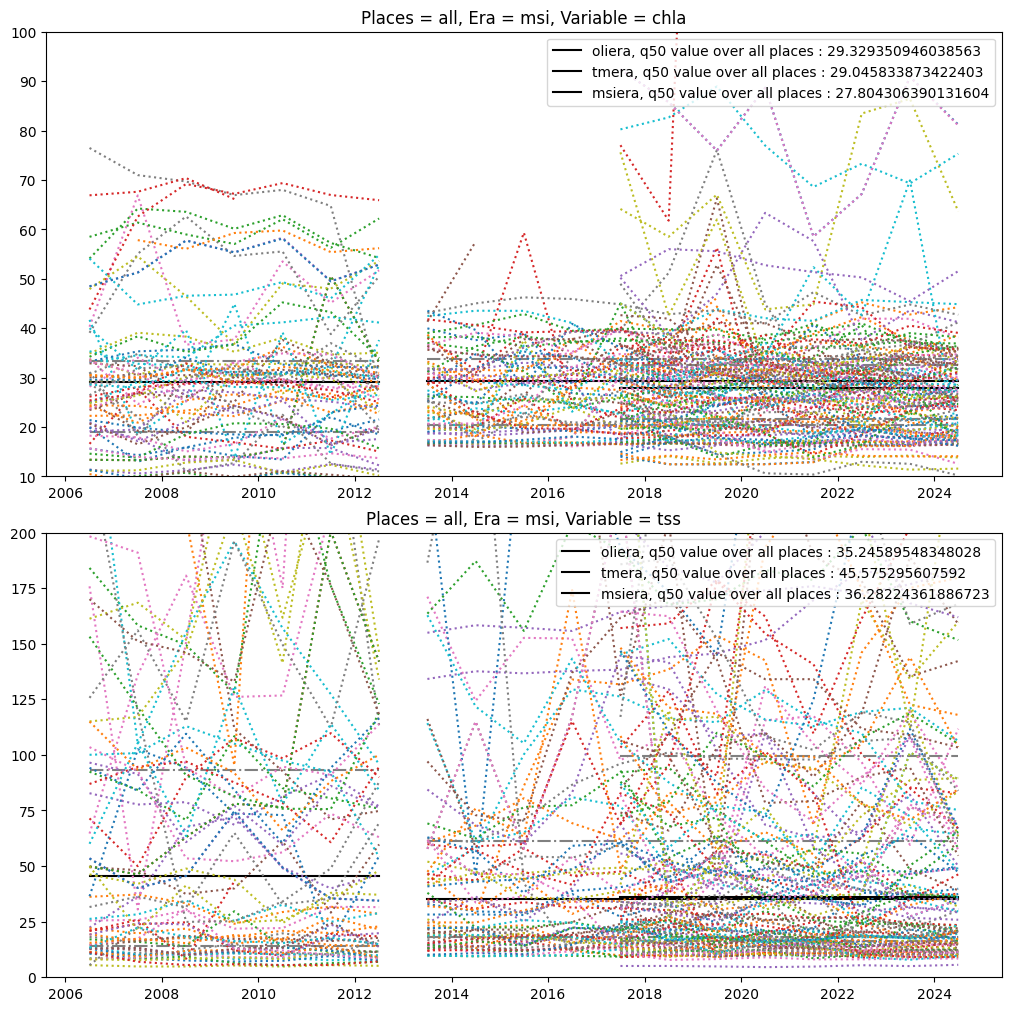

In [887]:
i =-1
verbose = True
fig, axes = plt.subplots(2,1,sharex=False, sharey=False, layout="constrained")    
fig.set_size_inches(10,10)

for var in ['chla','tss'] :
    i = i +1
    axis = axes[i]
    for era in 'oli','tm','msi':
    
        places    = wq_results.place
        times = x =  era_dates[era]
        measures  =  (set(era_mmts[var][era]) - set(exclude_list))
        Q = [50]  # index 50 will be 0.5. This is a nicer way to handle it.  
        y = ((wq_results.loc[{
                'time'         : times,
                'place'        : places,
                var+'_measure' : list(measures),
                'quantile'     : wq_results['quantile'][Q],
                }] \
                [var] * \
                      wq_results.loc[{var+'_measure' : list(measures)}][var+'_scale']) +\
                      wq_results.loc[{var+'_measure' : list(measures)}][var+'_offset']) \
                .median(dim=(var+'_measure')) \
                .median(dim=('time'))
        y25,y50,y75 = y.squeeze().quantile((0.25,0.5,.75),dim=('place')).values
        
        era_medians[era][var] = y50

        axis.plot((times[0].values,times[-1].values),(y50,y50),linestyle='-',color='k',label = era+'era, q50 value over all places : '+str(y50))
        axis.plot((times[0].values,times[-1].values),(y25,y25),linestyle='-.',color='grey',)
        axis.plot((times[0].values,times[-1].values),(y75,y75),linestyle='-.',color='grey',)
        axis.set_title('Places = all, Era = '+era+', Variable = '+var)    
        axis.set_ylim(10,100)
        if var =='tss' : plt.ylim(0,200)
        ls = ':'

        for place in places:
            y = (wq_results.loc[{
                    'time'         : times,
                    'place'        : place,
                    var+'_measure' : list(measures),
                    'quantile'     : wq_results['quantile'][Q],
                    }][var] * \
                         wq_results.loc[{var+'_measure' : list(measures)}][var+'_scale'] +\
                         wq_results.loc[{var+'_measure' : list(measures)}][var+'_offset']).\
                             median(dim=(var+'_measure')).squeeze()
                 
            axis.plot(times,y,linestyle=ls)

    axis.legend(loc='upper right')
plt.show()
        

In [888]:
era_medians

{'tm': {'tss': np.float64(45.575295607592),
  'chla': np.float64(29.045833873422403)},
 'oli': {'tss': np.float64(35.24589548348028),
  'chla': np.float64(29.329350946038563)},
 'msi': {'tss': np.float64(36.28224361886723),
  'chla': np.float64(27.804306390131604)},
 'tm_sf': {'tss': 1, 'chla': 1},
 'oli_sf': {'tss': 1, 'chla': 1},
 'msi_sf': {'tss': 1, 'chla': 1}}

In [889]:
# 4.2 --- calculate the era to era scale factors (and save to era_adjustment_factors.csv ) :

refera = 'msi'
for var in 'tss','chla' :
    reference_median = era_medians[refera][var]  
    for era in 'tm','oli','msi' :
        era_medians[era+'_sf'][var] = reference_median / era_medians[era][var] 

# save as a csv file that can be read back into a dataframe
df = pd.DataFrame(era_medians).rename(columns = {'tm':'tm_era_mean', 'oli':'oli_era_mean','msi':'msi_era_mean'})
df.to_csv(WP22+'/'+'era_adjustment_factors.csv')
df

,tm_era_mean,oli_era_mean,msi_era_mean,tm_sf,oli_sf,msi_sf
tss,45.575296,35.245895,36.282244,0.796095,1.029403,1.0
chla,29.045834,29.329351,27.804306,0.957256,0.948003,1.0


In [895]:
scalefactor

np.float64(0.7960945318108541)

In [897]:
# 4.3 --- save the era adjustment factors into the results dataset, using the measurement dimension

for var in 'tss','chla':
    print('\nProcessing '+var,':')
    newvarname   =  var+'_era_factor'   
    wq_results[newvarname] = (var+'_measure'), np.ones(wq_results[var+'_measure'].size)
    for era in ['tm','oli','msi']:
        print('era = '+era)
        measurements = era_mmts[var][era]
        print('measurements to process = ',measurements)
        for measurement in measurements:
            #print(measurement)
            scalefactor = era_medians[era+'_sf'][var]
            #print(scalefactor)
            wq_results[newvarname].loc[{var+'_measure' : measurement}] = scalefactor
    wq_results[newvarname]


pd.DataFrame((pd.DataFrame([wq_results.tss_measure.values,wq_results.chla_era_factor.values]).T))


Processing tss :
era = tm
measurements to process =  ['ndssi_rg_tm', 'ti_yu_tm', 'tsm_lym_tm', 'tss_grb_tm', 'tss_gr_tm', 'spm_qiu_tm']
era = oli
measurements to process =  ['ndssi_rg_oli', 'ndssi_bnir_oli', 'ti_yu_oli', 'tsm_lym_oli', 'tss_grb_oli', 'tss_gr_oli']
era = msi
measurements to process =  ['ndssi_rg_msi', 'tsm_lym_msi', 'tss_grb_msi', 'tss_gr_msi', 'spm_qiu_msi']

Processing chla :
era = tm
measurements to process =  ['ndci_tm43', 'chla_3bda_tm', 'chla_tebbs_tm', 'chla_modis2b_tm']
era = oli
measurements to process =  ['ndci_oli54', 'chla_3bda_oli', 'chla_tebbs_oli']
era = msi
measurements to process =  ['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'chla_gurlin2b_msi', 'chla_toming_msi', 'chla_3bda_msi', 'chla_tebbs_msi', 'chla_meris2b_msi', 'chla_modis2b_msi']


,0,1
0,ndssi_rg_msi,1.0
1,ndssi_rg_oli,1.0
2,ndssi_rg_tm,1.0
3,ndssi_bnir_oli,0.957256
4,ti_yu_oli,0.948003
5,ti_yu_tm,1.0
6,tsm_lym_oli,1.0
7,tsm_lym_msi,1.0
8,tsm_lym_tm,0.948003
9,tss_grb_msi,0.957256


#### Step 5, deal with fai and hue

#### Final Step, convert to dataframe and save to a csv file :

In [898]:
# produce a datafram for each set of variables and then combine them
#

tss_np = pd.DataFrame(wq_results.tss_measure,columns=['measurement'])
tss_np ['var']         = 'tss'
tss_np ['offset']      = wq_results.tss_offset
tss_np ['scale' ]      = wq_results.tss_scale
tss_np ['era_factor' ] = wq_results.tss_era_factor


chla_np = pd.DataFrame(wq_results.chla_measure,columns=['measurement'])
chla_np ['var']         = 'chla'
chla_np['offset']     = wq_results.chla_offset
chla_np['scale' ]     = wq_results.chla_scale
chla_np['era_factor'] = wq_results.chla_era_factor

np_params = pd.concat([tss_np,chla_np]).reset_index(drop=True)
np_params

,measurement,var,offset,scale,era_factor
0,ndssi_rg_msi,tss,81.386421,203.026005,1.000000
1,ndssi_rg_oli,tss,61.765478,192.552973,1.029403
2,ndssi_rg_tm,tss,97.290712,270.172143,0.796095
3,ndssi_bnir_oli,tss,52.670338,80.232365,1.029403
4,ti_yu_oli,tss,4.372455,194.440452,1.029403
5,ti_yu_tm,tss,2.465631,290.300096,0.796095
6,tsm_lym_oli,tss,0.000000,1.000000,1.029403
7,tsm_lym_msi,tss,4.026285,1.176149,1.000000
8,tsm_lym_tm,tss,4.004789,1.337684,0.796095
9,tss_grb_msi,tss,7.302746,0.897655,1.000000


In [903]:
pd.read_csv(data_directory+np_parameters_filename,index_col = 0).to_csv('old_normalisation_parameters.csv',index=False)

In [904]:
np_params.to_csv(data_directory+np_parameters_filename,index=False)
print('\n .... saved to ',np_parameters_filename)
np_params


 .... saved to  normalisation_parameters.csv


,measurement,var,offset,scale,era_factor
0,ndssi_rg_msi,tss,81.386421,203.026005,1.000000
1,ndssi_rg_oli,tss,61.765478,192.552973,1.029403
2,ndssi_rg_tm,tss,97.290712,270.172143,0.796095
3,ndssi_bnir_oli,tss,52.670338,80.232365,1.029403
4,ti_yu_oli,tss,4.372455,194.440452,1.029403
5,ti_yu_tm,tss,2.465631,290.300096,0.796095
6,tsm_lym_oli,tss,0.000000,1.000000,1.029403
7,tsm_lym_msi,tss,4.026285,1.176149,1.000000
8,tsm_lym_tm,tss,4.004789,1.337684,0.796095
9,tss_grb_msi,tss,7.302746,0.897655,1.000000


In [1512]:
xr.Dataset.from_dataframe(np_params)

<xarray.Dataset> Size: 1kB
Dimensions:     (index: 32)
Coordinates:
  * index       (index) int64 256B 0 1 2 3 4 5 6 7 8 ... 24 25 26 27 28 29 30 31
Data variables:
    variable    (index) object 256B 'ndssi_rg_msi' ... 'chla_modis2b_tm'
    offset      (index) float64 256B 72.37 58.96 84.89 ... -71.15 0.0 -6.188
    scale       (index) float64 256B 175.1 185.9 236.7 ... 5.516 1.0 0.9784
    era_factor  (index) float64 256B 1.0 1.062 0.8401 1.062 ... 1.0 1.0 0.9543

In [1509]:
wq_results

<xarray.Dataset> Size: 43MB
Dimensions:          (place: 66, quantile: 101, time: 25, tss_measure: 17,
                      chla_measure: 15)
Coordinates:
  * place            (place) <U18 5kB 'Barrage Joumine' ... 'mombasa'
  * quantile         (quantile) float64 808B 0.0 0.01 0.02 ... 0.98 0.99 1.0
  * time             (time) datetime64[ns] 200B 2000-07-01T23:59:59.999999 .....
  * tss_measure      (tss_measure) <U14 952B 'ndssi_rg_msi' ... 'spm_qiu_msi'
  * chla_measure     (chla_measure) <U16 960B 'ndci_msi54' ... 'chla_modis2b_tm'
    spatial_ref      int32 4B 6933
Data variables:
    tss              (place, quantile, time, tss_measure) float64 23MB nan .....
    chla             (place, quantile, time, chla_measure) float64 20MB nan ....
    tss_offset       (tss_measure) float64 136B 72.37 58.96 ... -59.22 -16.18
    tss_scale        (tss_measure) float64 136B 175.1 185.9 ... 6.662 3.009
    chla_offset      (chla_measure) float64 120B 175.1 135.3 0.0 ... 0.0 -6.188
    chla_scale       (chla_measure) float64 120B 376.2 217.0 0.0 ... 1.0 0.9784
    tss_era_factor   (tss_measure) float64 136B 1.0 1.062 0.8401 ... 0.8401 1.0
    chla_era_factor  (chla_measure) float64 120B 1.0 1.0 1.0 ... 1.0 1.0 0.9543

### Inspect results :


#### Chl-A :


In [1384]:
# --- check some of the results, applying the era scale factors ---
# some other useful sets of measurements for exploring chla measures
fullset = ['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43',
       'ndci_oli54', 'chla_toming_msi', 'chla_3bda_msi', 'chla_3bda_oli',
       'chla_3bda_tm', 'chla_tebbs_msi', 'chla_tebbs_oli',
       'chla_tebbs_tm', 'chla_meris2b_msi', 'chla_modis2b_msi',
       'chla_modis2b_tm']
ndciset = ['ndci_msi54', 'ndci_msi64', 'ndci_msi74', 'ndci_tm43',     'ndci_oli54']
chla_3bdaset = ['chla_toming_msi', 'chla_3bda_msi', 'chla_3bda_oli',   'chla_3bda_tm']
tebbsset =  ['chla_tebbs_msi', 'chla_tebbs_oli',     'chla_tebbs_tm']
modisset = ['chla_meris2b_msi', 'chla_modis2b_msi',  'chla_modis2b_tm']



In [1387]:
i = 0

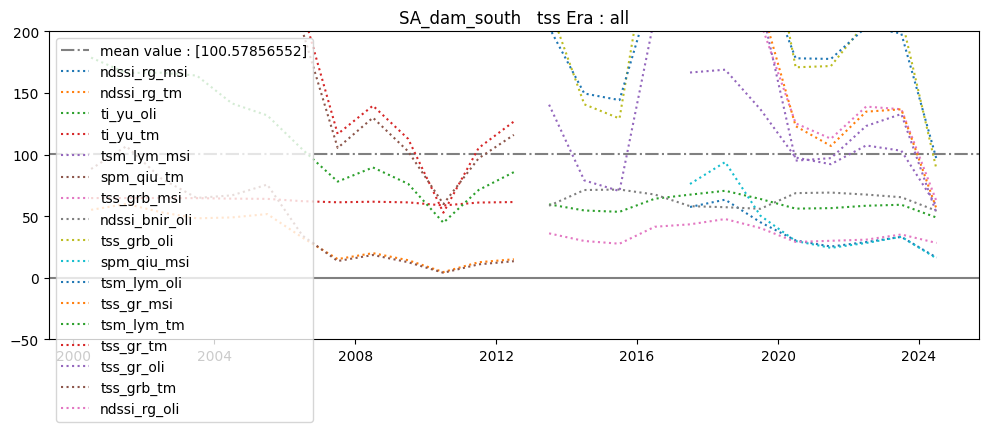

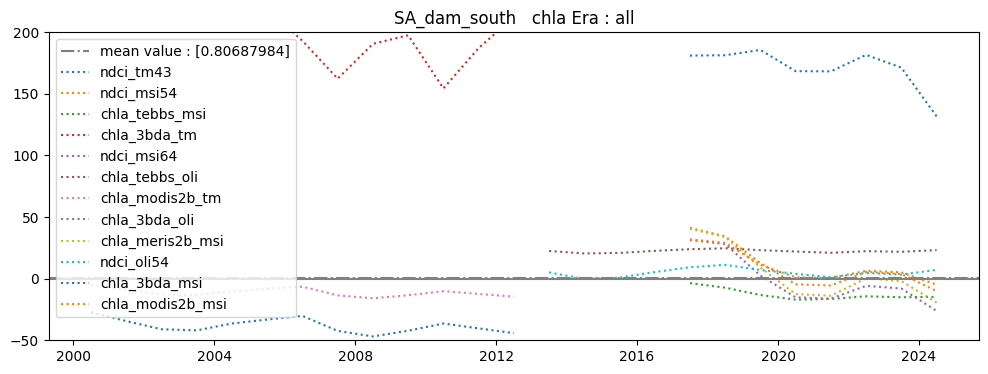

In [1456]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
#i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
i = i + 1

placename = wq_results.place[i].item()
    
reftime    =  wq_results.time[0:25]   
targettime =  wq_results.time[0:25]  
displaytime = wq_results.time[0:25]
tm_era       = wq_results.time[0:13]
msi_era      = wq_results.time[17:25]
oli_era      = wq_results.time[13:17]

# display overall results per measurement to detect problem measurements
# also capture the median values for each era for tss and chla
# medians = {}
#medians['tss'] = {}
#medians['chla'] = {}
era = 'all'
for var in ['tss','chla'] :
        mmt_list = []
        for name in wq_results[var+'_measure']:
            mmt_list.append(name.item())
        places    = placename
        times = x =  era_dates[era]
        measures  =  set(mmt_list) - set(exclude_list)
        Q = [50]  # index 50 will be 0.5. This is a nicer way to handle it.  
               
        y_median = ((((wq_results.loc[{
                'time'         : times,
                'place'        : [places],
                var+'_measure' : list(measures),
                'quantile'     : wq_results['quantile'][Q],
                }] \
                [var] * \
                      wq_results.loc[{var+'_measure' : list(measures)}][var+'_scale']) +\
                      wq_results.loc[{var+'_measure' : list(measures)}][var+'_offset'])   )\
                      * wq_results.loc[{var+'_measure' : list(measures)}][var+'_era_factor']) \
                .median(dim=('place')) \
                .median(dim=(var+'_measure')) \
                .mean(dim=('time'))\
                .values

        if verbose: 
            fig, ax = plt.subplots(1, 1, figsize=(12, 4))
            plt.axhline(y_median,linestyle='-.',color='grey',label = 'mean value : '+str(y_median))
            plt.title(placename + '   '+var+' Era : '+era)    
            plt.ylim(-50,200)
            for measure in measures :     #wq_results[var+'_measure'].values:
                y = ((((wq_results.loc[{
                    'time'         : times,
                    'place'        : [places],
                    var+'_measure' : measure,
                    'quantile'     : wq_results['quantile'][Q],
                    }] [var] * \
                          wq_results.loc[{var+'_measure' : measure}][var+'_scale']) +\
                          wq_results.loc[{var+'_measure' : measure }][var+'_offset'])) \
                         * wq_results.loc[{var+'_measure' : measure}][var+'_era_factor']) \
                        .median(dim=('place')).squeeze()
            
                ls = ':'
                plt.plot(x,y,linestyle=ls,label=measure)
            plt.axhline(0,linestyle='-',color='gray')
            plt.legend(loc='best')
            plt.show()    
        

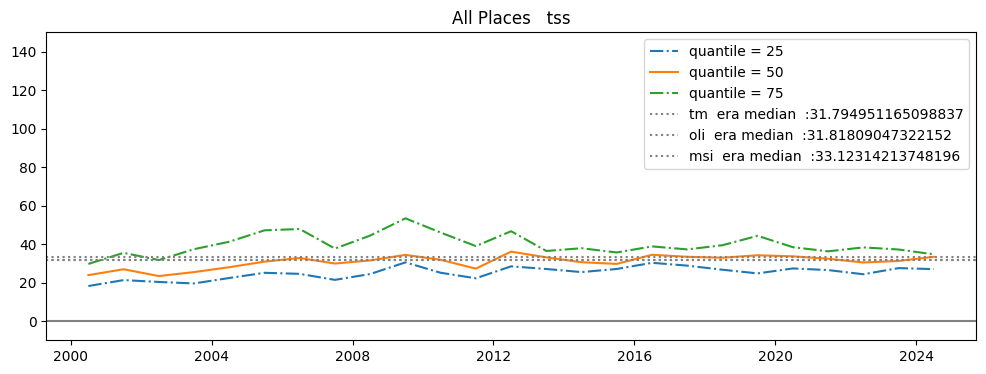

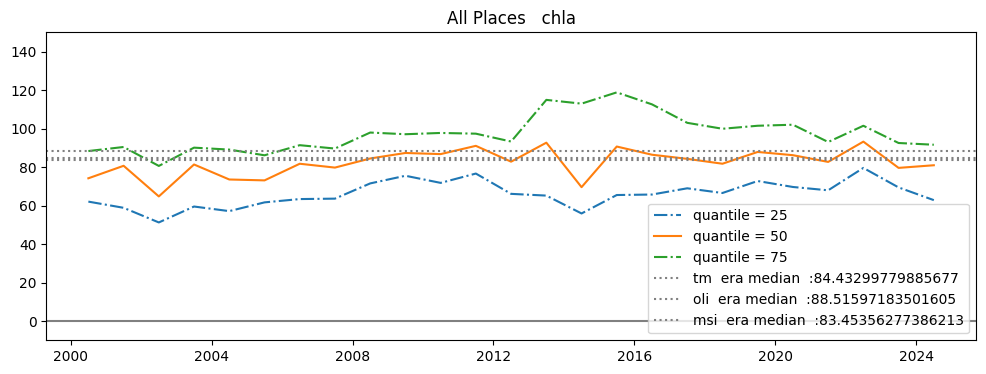

In [1457]:
#display overall results for all places to identify global biases / issues
# important to take the median of the measure for each place, THEN the median of the places, THEN the median over time
#plt.show()    # plot each measure individually
# get the median values overall for the eras
    
reftime    =  wq_results.time[0:25]   
targettime =  wq_results.time[0:25]  
displaytime = wq_results.time[0:25]
tm_era       = wq_results.time[0:13]
msi_era      = wq_results.time[17:25]
oli_era      = wq_results.time[13:17]

times = x = displaytime
places = wq_results.place.values
        
for var in ['tss','chla'] :
        measures = list(wq_results[var+'_measure'].values)
        measures = set(measures)  - set(exclude_list)
        
        fig, ax = plt.subplots(1, 1, figsize=(12, 4))
        plt.title('All Places   '+var)    
        plt.ylim(-10,150)
        

        #plt.figsize=(12, 4)
        for Q in [25,50,75] :
            y = ((((wq_results.loc[{
                    'time'  :  times,
                    'place' : places,
                    var+'_measure' : list(measures),
                    'quantile' : wq_results['quantile'][Q] \
                    }] \
                    [var]  * \
                         wq_results.loc[{var+'_measure'   : list(measures)}][var+'_scale']) +\
                         wq_results.loc[{var+'_measure'   : list(measures)}][var+'_offset'])   )\
                       * wq_results.loc[{var+'_measure'   : list(measures)}][var+'_era_factor']) \
                        .median(dim=(var+'_measure')) \
                        .median(dim=('place')) \
                        .values

            ls = ':'
            if Q == 50 : ls = '-'
            if Q in [25,75] : ls = '-.'
            plt.plot(x,y,linestyle=ls,label='quantile = '+str(Q))

        plt.axhline(0,linestyle='-',color='gray')
        #add lines for the medians for each era, 

        emed = {}
        for era in 'tm','oli','msi':
            emed[era] = ((((wq_results.loc[{
                                'time'         : era_dates[era],
                                'quantile'     : wq_results['quantile'][50],\
                                 var+'_measure' : list(measures),
                                 }]
                                    [var] * \
                                      wq_results.loc[{var+'_measure' : list(measures)}][var+'_scale'] ) \
                                      + wq_results.loc[{var+'_measure' : list(measures)}][var+'_offset'] )   ) \
                                      * wq_results.loc[{var+'_measure' : list(measures)}][var+'_era_factor']  \
                                    ).median(dim=(var+'_measure')).median(dim=('place')).median(dim=('time'))
            plt.axhline(emed[era], linestyle=':', color='gray' , label=era+'  era median  :' + str(emed[era].values))
        
        plt.legend(loc='best')
        plt.show()    

        

Ethiopia1of2


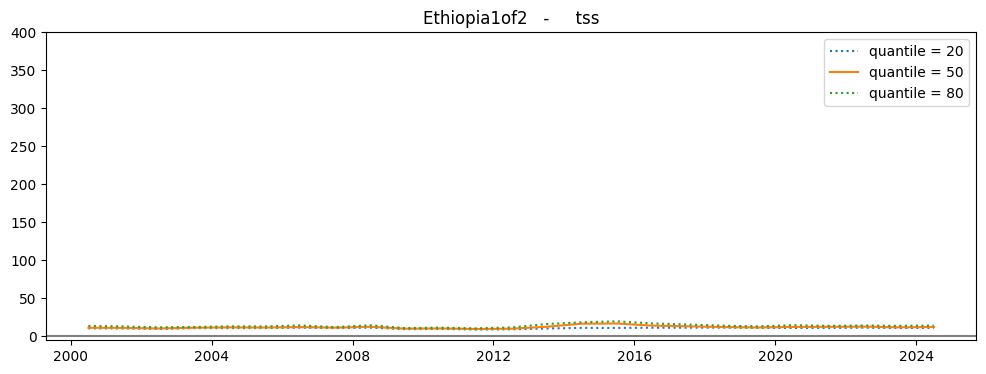

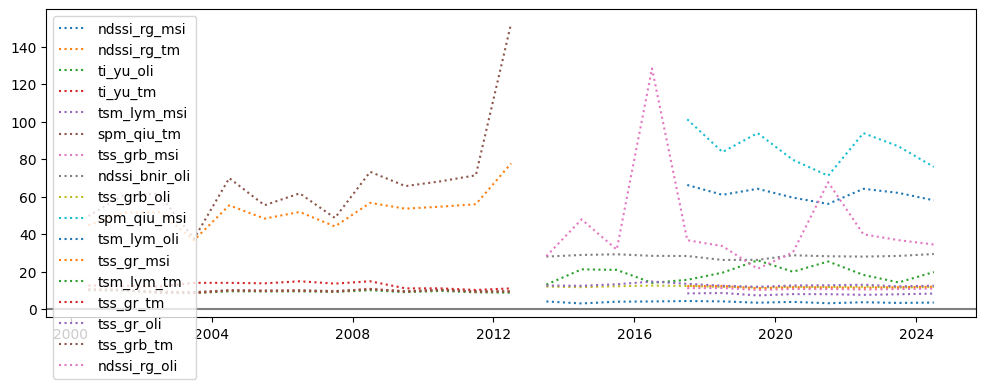

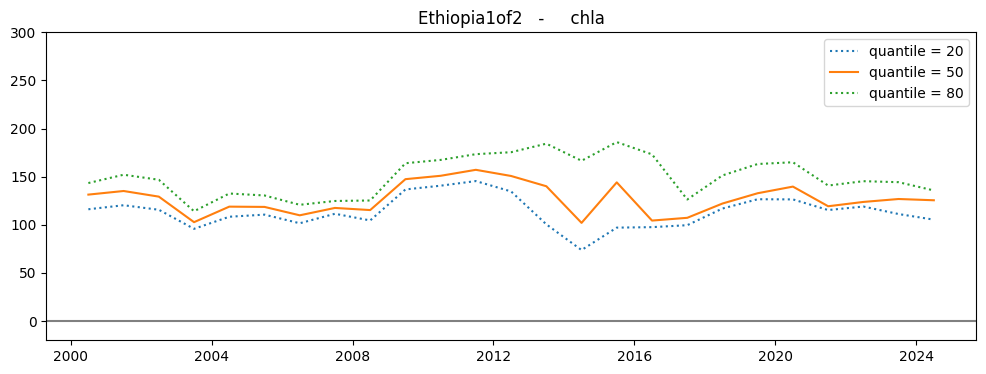

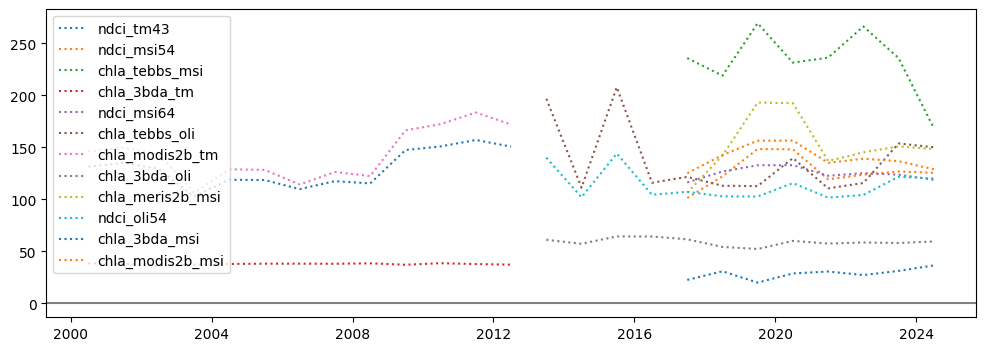

In [1391]:
# plot each measure individually for the place
rng = np.random.default_rng()
#i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
i = i +1
#i = 0

placename = wq_results.place[i].item()


times = x = displaytime
print(placename)
ylims = {'tss' : [-5,400],'chla':[-20,300]}

for var in ['tss','chla'] :
    measures = list(wq_results[var+'_measure'].values)
    measures = list(set(measures)  - set(exclude_list))
    # plot the median values through time and high and low values of the collective median
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    plt.title(placename+'   -     '+var)
    plt.ylim(ylims[var])
    for Q in [20,50,80]:
        y = ((((wq_results.loc[{
                                'time'         : displaytime,
                                'place'        : placename  ,
                                var+'_measure' : measures   ,
                                'quantile'     : wq_results['quantile'][Q] \
                                        }]\
                                        [var]\
                                        * wq_results.loc[{ var+'_measure' : measures }][var+'_scale' ]) \
                                        + wq_results.loc[{ var+'_measure' : measures }][var+'_offset'])) \
                                        + wq_results.loc[{ var+'_measure' : measures }][var+'_era_factor']) \
                                .median(dim=(var+'_measure')) \
                                .squeeze()
        ls = ':'
        if Q == 50 : ls = '-'
        if Q in [75,25] : ls = '-.'
        plt.plot(x,y,linestyle=ls,label='quantile = '+str(Q))
    plt.axhline(0,linestyle='-',color='gray')
    plt.legend(loc='best')
    plt.show()    
    
    # --- now plot each measure individually ....
    Q = 50

    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    for measure in measures:
        y = ((((wq_results.loc[{ \
                                'time'         : (displaytime),
                                'place'        : placename,
                                var+'_measure' : measure,
                                'quantile'     : wq_results['quantile'][Q],
                            }] \
                            [var] \
                              * wq_results.loc[{var+'_measure' : measure}][var+'_scale']) \
                              + wq_results.loc[{var+'_measure' : measure}][var+'_offset'])) \
                              + wq_results.loc[{var+'_measure' : measure}][var+'_era_factor']) \
                                .squeeze()
        ls = ':'
        if Q == 50 : ls = ':'
        if Q in [75,25] : ls = '-.'
        plt.plot(x,y,linestyle=ls,label=measure)
    plt.axhline(0,linestyle='-',color='gray')
    plt.legend(loc='best')
    plt.show()    # plot each measure individually

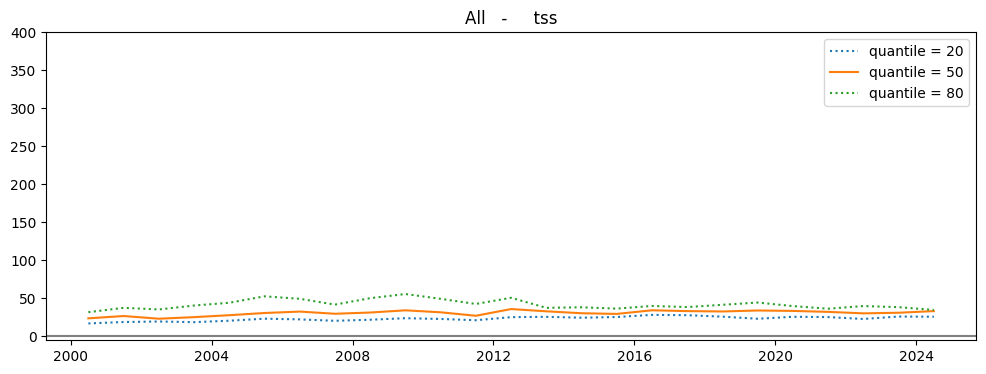

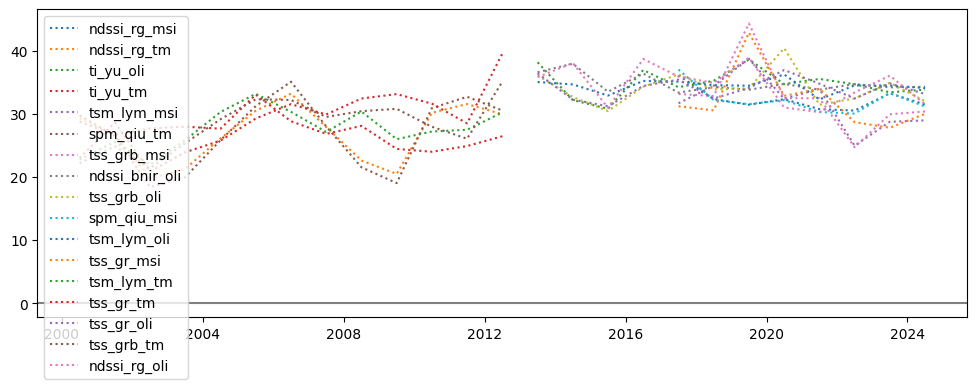

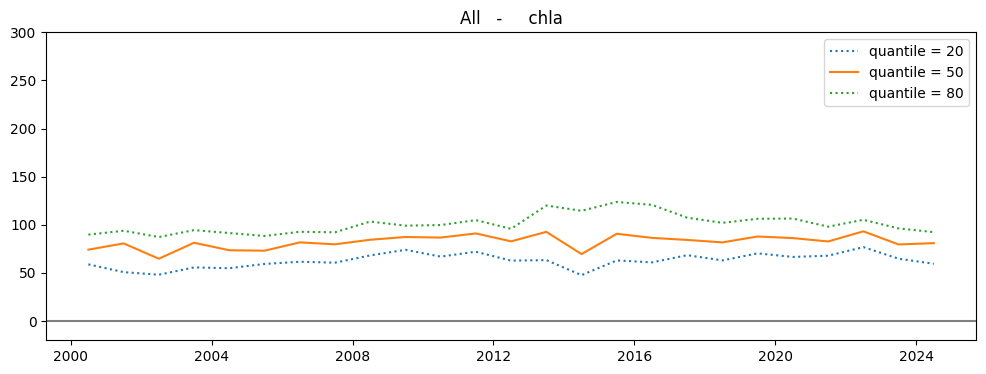

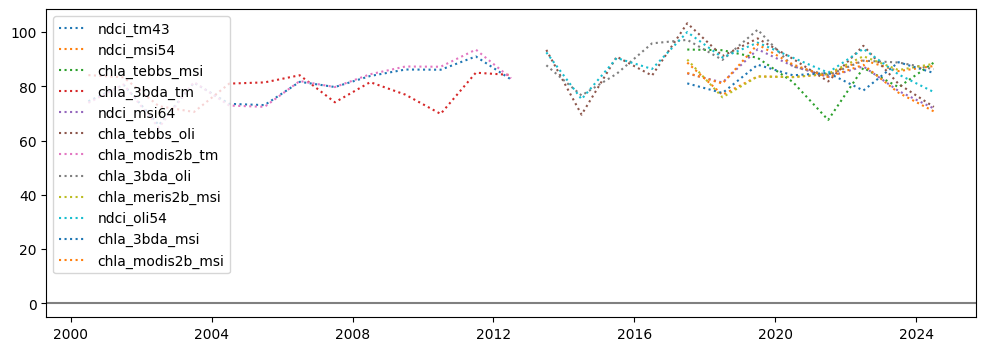

In [1458]:
#display measures aggregrated over  all places 
                            
for var in ['tss','chla'] :
    measures = list(wq_results[var+'_measure'].values)
    measures = list(set(measures)  - set(exclude_list))
    # plot the median values through time and high and low values of the collective median
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    plt.title('All'+'   -     '+var)
    plt.ylim(ylims[var])
    for Q in [20,50,80]:
        y = ((((wq_results.loc[{
                                'time'         : displaytime,
                                var+'_measure' : measures   ,
                                'quantile'     : wq_results['quantile'][Q] \
                                        }]\
                                        [var]\
                                        * wq_results.loc[{ var+'_measure' : measures }][var+'_scale' ]) \
                                        + wq_results.loc[{ var+'_measure' : measures }][var+'_offset'])) \
                                        * wq_results.loc[{ var+'_measure' : measures }][var+'_era_factor']) \
                                .median(dim=(var+'_measure')) \
                                .median(dim=('place')) \
                                .squeeze()
        ls = ':'
        if Q == 50 : ls = '-'
        if Q in [75,25] : ls = '-.'
        plt.plot(x,y,linestyle=ls,label='quantile = '+str(Q))
    plt.axhline(0,linestyle='-',color='gray')
    plt.legend(loc='best')
    plt.show()    
    
    # --- now plot each measure individually ....
    Q = 50
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    for measure in measures:
        y = ((((wq_results.loc[{ \
                                'time'         : (displaytime),
                                var+'_measure' : measure,
                                'quantile'     : wq_results['quantile'][Q],
                            }] \
                            [var] \
                              * wq_results.loc[{var+'_measure' : measure}][var+'_scale']) \
                              + wq_results.loc[{var+'_measure' : measure}][var+'_offset'])) \
                              * wq_results.loc[{var+'_measure' : measure}][var+'_era_factor']) \
                                .median(dim=('place')) \
                                .squeeze()
        ls = ':'
        if Q == 50 : ls = ':'
        if Q in [75,25] : ls = '-.'
        plt.plot(x,y,linestyle=ls,label=measure)
    plt.axhline(0,linestyle='-',color='gray')
    plt.legend(loc='best')
    plt.show()    # plot each measure individually

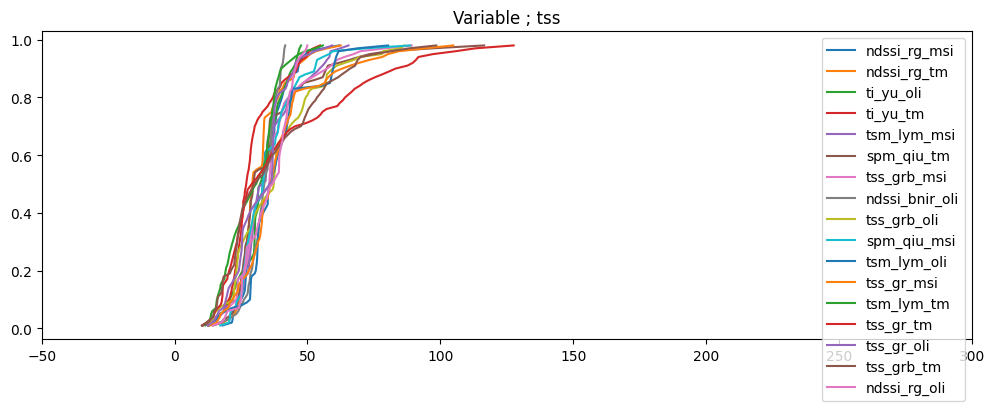

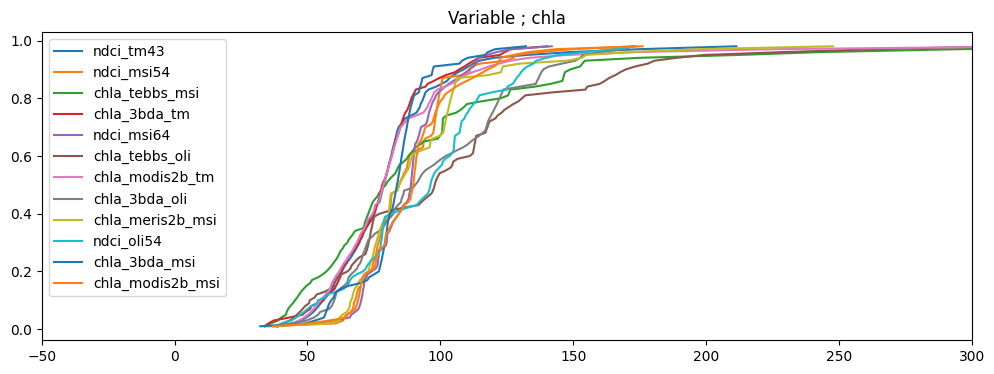

In [1453]:
# --- statistical distributions ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
rng = np.random.default_rng()
i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
    

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

for var in 'tss','chla':
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    plt.xlim(-50,300)
    plt.title('Variable ; '+var)
    measures = list (set(wq_results[var+'_measure'].values) - set(exclude_list))
    
    for name in measures:
        Q = wq_results['quantile'][1:99]
        wq_results['quantile'].loc[{'quantile' : Q}]
        y = wq_results['quantile'].loc[{'quantile' : Q}]
        x = ((((wq_results.loc[{
                               'time'         : displaytime,
                                var+'_measure' : name      ,
                                'quantile'     : Q         , \
                                        }]\
                                        [var]\
                                        * wq_results.loc[{ var+'_measure' : name }][var+'_scale' ]) \
                                        + wq_results.loc[{ var+'_measure' : name }][var+'_offset'])) \
                                        * wq_results.loc[{ var+'_measure' : name }][var+'_era_factor']) \
                                .median(dim=('time')) \
                                .median(dim=('place')) \
                                .squeeze()
    
        plt.plot(x,y,label=name,linestyle='-')
    plt.legend(loc='best')
    plt.show()


#### Demonstrates the *dynamic application* of the scale and offset parameters:

In [1459]:
ds.tss.mean(dim=('time','tss_measure')).plot()
plt.show()
(((ds.tss * ds.tss_scale) + ds.tss_offset) + ds.tss_era_factor).mean(dim=('time','tss_measure')).plot()
plt.show()

NameError: name 'ds' is not defined

#### TSS :


SA_dam_south


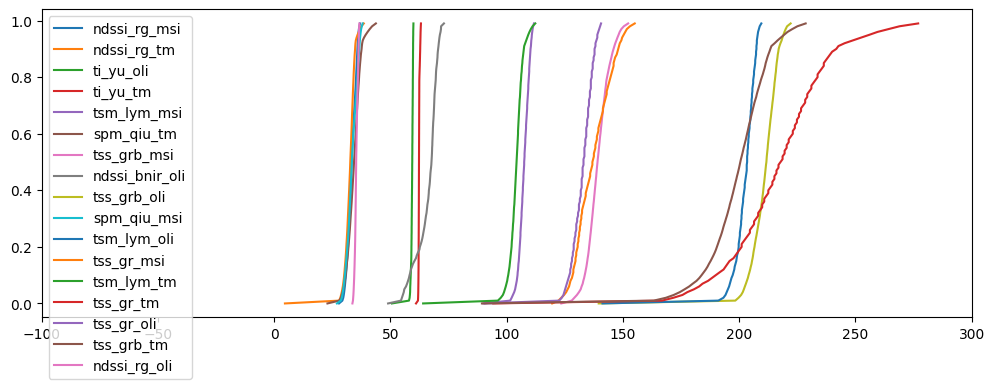

In [1460]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
#rng = np.random.default_rng()
#i = rng.integers(size=1,low=0,high=wq_results.place.size).item()
i = i
placename = wq_results.place[i].item()
#print(placename)


    
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
plt.xlim(-100,300)

exclude = ['chla_tebbs_oli','chla_tebbs_msi','chla_tebbs_tm']
exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

print(placename)

for name in (set(wq_results.tss_measure.values) - set(exclude)):
    scale  =  wq_results.loc[dict(tss_measure = name)].tss_scale.item()
    offset =  wq_results.loc[dict(tss_measure = name)].tss_offset.item()
    era_factor =  wq_results.loc[dict(tss_measure = name)].tss_era_factor.item()
    y = wq_results['quantile'][wq_results['quantile']<1]
    x = ((wq_results.loc[dict(time = (displaytime) ,
                             tss_measure=name ,
                             place = placename,
                             quantile=(wq_results['quantile'] <1))].tss.
                             median(dim=('time')) * scale) + offset) * era_factor
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()
i +=1

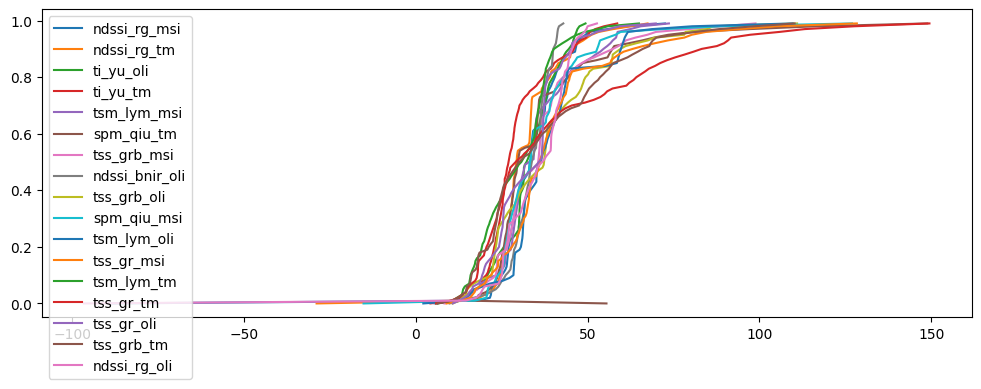

In [1476]:
# --- check some of the results ---
#     a little bit of analysis and normalisation to be able to view the results comparatively
   
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
#plt.xlim(0,300)

exclude = []

reftime    =  wq_results.time[0:24]   
targettime =  wq_results.time[0:24]  
displaytime = wq_results.time[0:24]

for name in (set(wq_results.tss_measure.values) - set(exclude_list)):
    y = wq_results['quantile'][wq_results['quantile']<1]
    scale  = wq_results.loc[dict(tss_measure=name)].tss_scale
    offset = wq_results.loc[dict(tss_measure=name)].tss_offset
    era_factor =  wq_results.loc[dict(tss_measure = name)].tss_era_factor.item()

    x = ((wq_results.loc[dict(time = (displaytime) ,
                             tss_measure=name ,
                             quantile=(wq_results['quantile'] <1))].tss.
                             median(dim=('time')).median(dim=('place')) * scale) + offset) * era_factor
    plt.plot(x,y,label=name)
plt.legend(loc='best')
plt.show()


# Part C, Calibration to in-situ data

## Steps I think:
1. Load the reference point datasets - in-situ data
2. Produce results for tss, chla in the vicinity of these data points
3. Allocate observed values to the observation points
4. Develop a function to translate from observed to in-situ


In [1]:
# ---  dependencies --- 

import datacube
import numpy as np
import xarray as xr
import scipy as sp
import gc
import json
from   scipy import stats
import pandas as pd     #for dates
from   odc.ui import image_aspect
from   deafrica_tools.plotting import rgb 
import geopandas as gpd
#from   shapely.geometry import Point
#import seaborn as sns
#from   odc.geo.geom import Geometry

# used in some visualisation for debugging
#dc = datacube.Datacube(app='DoinWhatImdoin') #testing what difference the 'app' value makes...

In [2]:
# --- pathnames 
# results files are stored in my space for now
results_directory = '/home/jovyan/deafrica_water_quality/wq_results/'
WP12              = '/home/jovyan/dev/deafrica_water_quality/WP1.2/'
WP22              = '/home/jovyan/dev/deafrica_water_quality/WP2.2/'
data_directory    = '/home/jovyan/dev/deafrica_water_quality/src/water_quality/data/'
all_results_filename    = 'wq_raw'
annual_results_filename  = 'annsummary'
parta_results_filename   = '22A'
partc_results_filename   = '22C'
distributions_filename = 'measurment_distributions.nc'
lookup_table_filename  = 'targ_ref_lookup.csv'
np_parameters_filename = 'normalisation_paramters.csv'


In [3]:
# --- run code for functions that are called
%run /home/jovyan/dev/deafrica_water_quality/WP2.2/_WP2.2_functions.py   
%run /home/jovyan/dev/deafrica_water_quality/WP1.2/_WQ_functions.py

## 1. Load reference data

In [919]:
# functions from fang to read data

def flag_type(flag):
    if pd.isna(flag):
        return "normal"
    elif "<" in str(flag):
        return "below"
    elif ">" in str(flag):
        return "above"
    else:
        return "normal"
        
def read_insitu(parameter):

    df = pd.read_csv(f"samples_{parameter}.csv")

    df["datetime"]  = pd.to_datetime(df['Sample Date'] + " " + df['Sample Time'], errors='coerce')
    #df = df[df["Station Identifier"].str.contains("Lake Victoria")]
    df['flag_type'] = df['Value Flags'].apply(flag_type)

    units = df['Unit'].unique()
    if len(units)>1:
        to_update = df.Unit.str.startswith('mg')
        df.loc[to_update, 'Value'] = df.loc[to_update, 'Value']/1000.
        df.loc[to_update, 'Unit'] = df.loc[to_update, 'Unit'].str.replace(r'^m', 'µ', regex=True)
        units = df['Unit'].unique()
        if len(units)>1:
            print(f"Multiple units found for {parameter}: {units}")
    return df

In [920]:
# read in the data for chla and tss
chla = read_insitu('Chl-a')
tss = read_insitu('tss')
data={}
data['chla'],data['tss'] = chla,tss

In [921]:
# insert a unique observation number
chla.insert(0,'observation',chla.index)
tss.insert(0,'observation',tss.index)

In [922]:
# get a unique list of stations and count the number of observations ...

stations = pd.concat(
        (chla[['GEMS Station Number','Latitude','Longitude']].drop_duplicates(),
         tss [['GEMS Station Number','Latitude','Longitude']].drop_duplicates(),
        )).drop_duplicates()

stations = stations.set_index('GEMS Station Number')
#tss[['GEMS Station Number','Latitude','Longitude']].drop_duplicates()),axis=0).head()
#rename(columns={'flag_type':'sample_count'})
#tss.groupby('GEMS Station Number').count()

# for each station count the tss and chla observations, join to a single file, convert nans to zeros, convert to integers ... (!)

stations['count_total'] = 0
for mmt in 'chla','tss' :
    stations = stations.join(
        pd.DataFrame(data[mmt].groupby('GEMS Station Number').count()['flag_type']).\
            rename(columns={'flag_type': mmt+'_count'}))
    stations.loc[pd.isnull(stations[mmt+'_count']),mmt+'_count'] = 0
    stations[mmt+'_count']  = \
        stations[mmt+'_count'].values.astype('int')
    stations.rename(inplace=True,columns={mmt+'_count' : 'count_'+mmt})
    stations['count_total'] = stations['count_total'] + stations['count_'+mmt]
    stations = stations.join(
        pd.DataFrame(data[mmt].groupby('GEMS Station Number')['Sample Date'].min()).rename(columns={'Sample Date' : 'date_start_'+mmt}))
    stations = stations.join(
        pd.DataFrame(data[mmt].groupby('GEMS Station Number')['Sample Date'].max()).rename(columns={'Sample Date' : 'date_end_'+mmt}))
    stations.loc[pd.isnull(stations['date_start_'+mmt]),'date_start_'+mmt]  = ''
    stations.loc[pd.isnull(stations['date_end_'+mmt]),'date_end_'+mmt]  = ''
stations = stations.sort_values('count_total',ascending=False)

In [923]:
stations.head()

,Latitude,Longitude,count_total,count_chla,date_start_chla,date_end_chla,count_tss,date_start_tss,date_end_tss
GEMS Station Number,,,,,,,,,
ZAF00017,-25.724700,27.850000,1333,1333,2000-01-11,2010-12-14,0,,
TZA00022,-2.310217,32.838390,322,166,2000-09-12,2016-01-08,156,2001-01-21,2016-01-08
TZA00015,-2.590800,32.868350,252,130,2000-12-14,2016-01-07,122,2000-12-14,2016-01-07
TZA00016,-2.617783,32.853467,228,119,2000-01-20,2016-01-07,109,2000-12-14,2016-01-07
TZA00023,-2.141067,32.464950,199,107,2000-08-29,2016-01-09,92,2001-07-20,2016-01-09


In [924]:
# save the in-situ data and the station details as a csv / pandas dataframe
stations.to_csv('GEMS Stations.csv')

## 2. Build data cubes corresponding to the in-situ sites (assume fewer than 50)

In [933]:
# set the datacube parameters
placename = 'ZAF00017'
#x,y = 27.8491, -25.72649  # for the SA site which looks dodgy

# --- dictionaries for the non-geomedian instruments and products ...
instruments_to_use = {
    'oli_agm'  : {'use': False },
    'oli'      : {'use': True},
    'msi_agm'  : {'use': False },
    'msi'      : {'use': True},
    'tm_agm'   : {'use': False },
    'tm'       : {'use': True},
    'tirs'     : {'use': True},  
    'wofs_ann' : {'use': False },
    'wofs_all' : {'use': False },  # wofs_all will be removed as it is better to derive from wofs_ann
    }

# for the non-geomedian datasets, the build function wants to know the products ... 

products = { 
                'tm_agm'  :["gm_ls5_ls7_annual"],
                'tm'      :["ls5_sr","ls7_sr"],
                'oli_agm' :["gm_ls8_annual","gm_ls8_ls9_annual"],
                'oli'     :["ls8_sr","ls9_sr"],
                'msi_agm' :["gm_s2_annual"],
                'msi'     :["s2_l2a"],
                'tirs'    :["ls5_st","ls7_st","ls8_st","ls9_st"],
                'wofs_ann':["wofs_ls_summary_annual"],
                'wofs_all':["wofs_ls_summary_alltime"],
               }

instruments,measurements,rename_dict = instruments_list(instruments_to_use) 
data_list = {}



In [934]:
dc = datacube.Datacube(app='WP22_C') 

In [935]:
stations

,Latitude,Longitude,count_total,count_chla,date_start_chla,date_end_chla,count_tss,date_start_tss,date_end_tss
GEMS Station Number,,,,,,,,,
ZAF00017,-25.724700,27.850000,1333,1333,2000-01-11,2010-12-14,0,,
TZA00022,-2.310217,32.838390,322,166,2000-09-12,2016-01-08,156,2001-01-21,2016-01-08
TZA00015,-2.590800,32.868350,252,130,2000-12-14,2016-01-07,122,2000-12-14,2016-01-07
TZA00016,-2.617783,32.853467,228,119,2000-01-20,2016-01-07,109,2000-12-14,2016-01-07
TZA00023,-2.141067,32.464950,199,107,2000-08-29,2016-01-09,92,2001-07-20,2016-01-09
TZA00024,-1.860817,32.546367,197,94,2001-01-22,2016-01-09,103,2000-12-13,2016-01-09
TZA00018,-2.711883,32.868250,193,103,2000-01-11,2016-01-07,90,2000-12-14,2014-08-06
TZA00026,-2.299667,32.095250,162,83,2001-07-21,2016-09-01,79,2001-07-21,2016-01-09
TZA00019,-2.774050,32.897483,138,71,2000-12-14,2016-07-08,67,2000-12-14,2014-08-06


In [979]:
placename = 'TZA00022'
placename = 'ZAF00017'

verbose = False
test    = False
over_write = False
for placename in stations.reset_index()['GEMS Station Number']:
    # .... and GO !


    x,y,*t = stations.loc[placename,['Longitude','Latitude','date_start_chla','date_end_chla','date_start_tss','date_end_tss']]
    if placename=='ZAF00017' :     x,y = 27.8491, -25.72649  # for the SA site to get into the water ...
    if placename=='ZAF00023' :     x,y = 29.35937, -25.42  # for the SA site to get into the water ...
    delta = .001  
    year1, year2 =  pd.to_datetime(t).min(), pd.to_datetime(t).max()
    x0 = x - delta
    x1 = x + delta
    y0 = y - delta
    y1 = y + delta
    xyt = {'x' : (x0,x1),'y' : (y0,y1), 'time' : (year1,year2)}
    grid_resolution = 20/100000
    cell_area = (grid_resolution * 100000) ** 2
    resampling_option = 'bilinear'


    parameters = store_parameters(placename,
                                          xyt,
                                          grid_resolution,
                                          cell_area,
                                          resampling_option,
                                          year1.year,
                                          year2.year)

    parameters['projection'] = 'epsg:4326'

    agm_filename = results_directory+partc_results_filename+'_'+placename+'_agm'+'.nc'  

    if os.path.exists(agm_filename) :
        if not over_write:
            print(placename+' agm results already done')
            ds_annual = read_dataset(agm_filename)
        else : print(placename+' agm results will be re-done; over_write = ',over_write) 
    else :    
        gm_years,gm_instruments_to_use = geomedian_instruments_and_years(parameters)
        # --- different years are needed for the geomedians to give a 5 year interval
        gm_parameters = parameters              # --- store the parameters for reference 
        gm_parameters['year1'] = gm_years[0]
        gm_parameters['year2'] = gm_years[1]
        # --- check the proposed years against the geomedian dataset dates ---
        gm_instruments_to_use = check_instrument_dates(gm_instruments_to_use,gm_years[0],gm_years[1],verbose=False)
        # --- get the full detail, the gm_instruments is used later, the other parts not 
        gm_instruments,gm_measurements,gm_rename_dict   = instruments_list(gm_instruments_to_use)
        
        print('... building the geomedian dataset for '+placename)
        ds_annual = build_agm_dataset(gm_parameters,gm_instruments_to_use)

        ds_annual = ds_annual.rename({'longitude':'x','latitude':'y'})

        ds_annual = detect_geomedian_instruments(ds_annual)
        ds_annual = calculate_agm_count(ds_annual)

        WFTH = water_frequency_threshold_high = 0.5    #this threshold targets areas that are as like as not to be water at any time.
        PWT  = permanent_water_threshold      = 0.875  #used to map annual permanent water (value arrived at through testing)
        SC   = sigma_coefficient              = 1.2    #used to map annual permanent water (value arrived at through tessting)
        ds_annual   = water_analysis(ds_annual,
                   water_frequency_threshold= WFTH,
                   wofs_varname             = 'wofs_ann_freq',
                   permanent_water_threshold= PWT,
                   sigma_coefficient        = SC,
                   verbose                  = True,
                   test                     = False)


        ds_annual              = WOFS_5_year_frequency(ds_annual,False)
        ds_annual['water_5yr'] = xr.where(ds_annual.wofs_5yr_freq>0.45,
                                                  ds_annual.wofs_5yr_freq.astype('bool'),np.nan)
        ds_annual              = geomedian_FAI(ds_annual,ds_annual.water_5yr)
        ds_annual              = geomedian_NDVI(ds_annual,ds_annual.water_5yr)
        ds_annual              = set_clearwater(ds_annual,'agm_fai','water_5yr','wofs_ann_water')
        ds_annual              = apply_R_correction(ds_annual,['msi_agm','oli_agm','tm_agm'],
                             water_mask=ds_annual.water_5yr,drop = True, test = False,verbose=False)
        #ds_annual = geomedian_hue(ds_annual,ds_annual.clearwater==True,test=False,verbose=True)
        #ds_annual = run_OWT(ds_annual,agm=True,verbose=True)
        print('running wq algorithms')
        algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='_agm')
        dummy,tsm_vlist  = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_tsm,  
                        gm_instruments, 
                        new_dimension_name=None, 
                        new_varname       =None, 
                        verbose=verbose)
        # this two-step process avoids masking other variables
        ds_annual[tsm_vlist] = dummy[tsm_vlist] 
            
        dummy,chla_vlist = WQ_vars(ds_annual.where(ds_annual.clearwater),
                        algorithms_chla, 
                        gm_instruments, 
                        new_dimension_name=None, 
                        new_varname       =None,
                        verbose=verbose)
        ds_annual[chla_vlist] = dummy[chla_vlist]
        #ds_annual = ds_annual.assign_attrs({'placename' : placename})
        ds_annual.drop_attrs().to_netcdf(agm_filename)
        del dummy
        gc.collect()
    

    results_filename  = results_directory+partc_results_filename+'_'+placename+'.nc'  

    if os.path.exists(results_filename) :
        if not over_write:
            print(placename+' results already done')
            ds = read_dataset(results_filename)

        else : print(placename+' results will be re-done; over_write = ',over_write) 

    else :    
        print(placename+' - > Processing the main datasets...')
        # build the datasets which are saved in a dictionary

        # confirm the instruments to use 
        instruments_to_use = check_instrument_dates(instruments_to_use,
                               pd.DatetimeIndex([parameters['xyt']['time'][0]]).year[0],
                               pd.DatetimeIndex([parameters['xyt']['time'][1]]).year[0],
                               verbose=False)

        # retreive the details of the instruments, measurements and renaming of variables
        instruments,measurements,rename_dict   = instruments_list(instruments_to_use)

        data_list             = build_dataset(parameters['xyt'],
                                           instruments_to_use,
                                           products,
                                           measurements,
                                           parameters['grid_resolution'],
                                           parameters['resampling_option'],
                                           rename_dict,
                                           projection = 'epsg:4326',
                                           verbose = True)

        for inst in data_list.keys():
            data_list[inst] = data_list[inst].rename({'longitude':'x','latitude':'y'})

        ds = add_vars_and_combine_datasets(data_list)

        #del data_list
        #gc.collect()
 

        ds = determine_water_area (ds,ds_annual)
        # we don't want a single water coverage since we are dealing with multiple years, so...
        # expand the water_5yr variable to all observations 
        ds['water_5yr'] = ds_annual.sel({'time':ds.time},method='nearest').water_5yr.assign_coords({'time': ds.time})
        ds['water_ann'] = ds_annual.sel({'time':ds.time},method='nearest').wofs_ann_water.assign_coords({'time': ds.time})

        qa_percent_threshold = 0.9
        ds = ds.where(ds['data_qapass'] > qa_percent_threshold,drop=True)
        gc.collect()

        ds = calc_ndvi(ds,ds.water_5yr,threshold=0)
        ds = calc_fai(ds,ds.water_5yr,threshold=0)
        ds = set_clearwater(ds,'fai','water_5yr','water_ann')

        # apply rayleigh correction
        ds = apply_R_correction(ds,['msi','oli','tm'],ds.clearwater,drop=True,test=False)

        print('running wq algorithms')
        algorithms_chla,algorithms_tsm = set_wq_algorithms(suffix='')
        dummy,tsm_vlist  = WQ_vars(ds.where(ds.clearwater),
                    algorithms_tsm,  
                    instruments, 
                    new_dimension_name='tss_measure', 
                    new_varname=None, 
                    verbose=verbose,
                    test=False)
        # this two-step process avoids masking other variables
        ds[tsm_vlist] = dummy[tsm_vlist]
        del(dummy)
        gc.collect()

        dummy,chla_vlist = WQ_vars(ds.where(ds.clearwater),
                    algorithms_chla, 
                    instruments, 
                    new_dimension_name='chla_measure', 
                    new_varname=None,
                    verbose=verbose,
                    test=False)
        ds[chla_vlist] = dummy[chla_vlist]
        del dummy
        gc.collect()
    

        # condense to the key varibles before saving
        ds['chla'] = ds[chla_vlist].to_array(dim = 'chla_measure')
        ds['tss'] = ds[tsm_vlist].to_array(dim = 'tss_measure')

        # harmonise the data

        # --- the lookup table links each measurement to a reference measurement
        lookup = pd.read_csv(data_directory+lookup_table_filename,index_col=0)

        # --- the distributions data has the statistical distributions of all variables, calculated on all images (not geomedians) for 2019 and 2020 over about 20 sites.
        #distributions =  xr.open_dataset(distributions_filename).load(); distributions.close()
        distributions =  pd.read_csv(data_directory+'measurement_distributions.csv')

        np_data = pd.read_csv(data_directory+np_parameters_filename)

        # --- remove bad variables which will otherwise cause problems with median, mean etc.
        for mmt  in np_data.loc[np_data.scale == 0].measurement.values:
            print('resetting to nan:', mmt)
            for var in 'tss','chla':
                if mmt in ds[var+'_measure']:
                    ds.loc[{var+'_measure' : mmt            }][var] = np.nan


        # Instrument to instrument harmonisation
        # loop through tss and chla data arrays withing the dataset...
        # loop through the variables in each case... 
        # assign revised values  back into the dataset 
        for mmt in 'tss','chla':
            vartype = mmt+'_measure'
            for varname in list(ds[vartype].values):
                ds[mmt].loc[{vartype :[varname]}]= \
                    harmonise_for_instrument(
                        ds[mmt].loc[{vartype :[varname]}],
                        varname,
                        lookup,
                        distributions,
                        test=False)

        # Variable to variable harmonisation
        # --- add the scale and offset parameters into the dataset for simplicity in the follwoing steps
        for var in ['chla','tss']:
            measures = ds[var+'_measure']
            for thing in ['scale','offset','era_factor']:
                ds[var+'_'+thing] = (var+'_measure'),np_data.set_index('measurement').loc[measures,thing]

        for var in ['tss','chla']:
            ds[var+'_h'] = \
            (((ds[var] \
             * ds[var+'_scale']) \
             + ds[var+'_offset']) \
             * ds[var+'_era_factor'])

        #ds = ds.assign_attrs({'placename' : placename})
        ds[['tss_h','chla_h','clearwater','ndvi','qa_score']].drop_attrs().to_netcdf(results_filename)

        print(placename+' -> results for dataset saved to: '+results_filename) 
        del ds
        gc.collect()
    print(placename+'  -> COMPLETED')

ZAF00017 agm results already done
ZAF00017 results already done
ZAF00017  -> COMPLETED
... building the geomedian dataset for TZA00022

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  tm_agm ...
loading data for  wofs_ann ...
---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)
running wq algorithms
TZA00022 - > Processing the main datasets...
building the tm dataset ...
... done.
Data list =  dict_keys(['tm']) 

... instrument datasets complete

running wq algorithms
TZA00022 -> results for dataset saved to: /home/jovyan/deafrica_water_quality/wq_results/22C_TZA00022.nc
TZA00022  -> COMPLETED
... building the geomedian dataset for TZA00015

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  tm_agm ...
loading data for  wofs_ann ...
---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)
running wq algorithms
TZA00015 - > Processing the main datasets...
building

/opt/venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


running wq algorithms
MAR00002 - > Processing the main datasets...
building the tm dataset ...
... done.
Data list =  dict_keys(['tm']) 

... instrument datasets complete

running wq algorithms
MAR00002 -> results for dataset saved to: /home/jovyan/deafrica_water_quality/wq_results/22C_MAR00002.nc
MAR00002  -> COMPLETED
... building the geomedian dataset for TZA00035

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  tm_agm ...
loading data for  wofs_ann ...
---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)
running wq algorithms
TZA00035 - > Processing the main datasets...
building the tm dataset ...
... done.
Data list =  dict_keys(['tm']) 

... instrument datasets complete

running wq algorithms
TZA00035 -> results for dataset saved to: /home/jovyan/deafrica_water_quality/wq_results/22C_TZA00035.nc
TZA00035  -> COMPLETED
... building the geomedian dataset for TZA00032

Building the Geomedian dataset:
loading data for 

/opt/venv/lib/python3.12/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


running wq algorithms
ZAF00018 - > Processing the main datasets...
building the tm dataset ...
... done.
Data list =  dict_keys(['tm']) 

... instrument datasets complete

running wq algorithms
ZAF00018 -> results for dataset saved to: /home/jovyan/deafrica_water_quality/wq_results/22C_ZAF00018.nc
ZAF00018  -> COMPLETED
... building the geomedian dataset for TZA00011

Building the Geomedian dataset:
loading data for  oli_agm ...
loading data for  tm_agm ...
loading data for  wofs_ann ...
---variable -->   oli01_agm   <-- anticipated but not found in the dataset (non-fatal)
running wq algorithms
TZA00011 - > Processing the main datasets...
building the tm dataset ...
... done.
Data list =  dict_keys(['tm']) 

... instrument datasets complete

running wq algorithms
TZA00011 -> results for dataset saved to: /home/jovyan/deafrica_water_quality/wq_results/22C_TZA00011.nc
TZA00011  -> COMPLETED
... building the geomedian dataset for TZA00028

Building the Geomedian dataset:
loading data for 

In [905]:
ds_annual = read_dataset('/home/jovyan/deafrica_water_quality/wq_results/22_C_TZA00020_agm.nc')

In [906]:
ds_annual

<xarray.Dataset> Size: 466kB
Dimensions:              (time: 14, y: 11, x: 11)
Coordinates:
  * time                 (time) datetime64[ns] 112B 2001-07-02T11:59:59.99999...
  * y                    (y) float64 88B -1.511 -1.511 -1.512 ... -1.513 -1.513
  * x                    (x) float64 88B 33.91 33.91 33.91 ... 33.91 33.91 33.91
    spatial_ref          int32 4B 4326
Data variables: (12/62)
    oli05_agm            (time, y, x) float32 7kB nan nan nan ... 215.0 215.0
    oli06_agm            (time, y, x) float32 7kB nan nan nan ... 180.0 180.0
    oli07_agm            (time, y, x) float32 7kB nan nan nan ... 151.0 151.0
    oli_agm_smad         (time, y, x) float32 7kB nan nan ... 0.02236 0.02188
    oli_agm_emad         (time, y, x) float32 7kB nan nan nan ... 154.7 152.2
    oli_agm_bcmad        (time, y, x) float32 7kB nan nan nan ... 0.1328 0.1267
    ...                   ...
    ndci_oli54           (time, y, x) float32 7kB nan nan nan ... 0.25 0.2536
    chla_3bda_oli        (time, y, x) float32 7kB nan nan ... 0.000491 0.0003952
    chla_3bda_tm         (time, y, x) float32 7kB 0.02089 0.02128 ... nan nan
    chla_tebbs_oli       (time, y, x) float32 7kB nan nan nan ... 616.7 622.5
    chla_tebbs_tm        (time, y, x) float32 7kB 337.0 334.8 334.4 ... nan nan
    chla_modis2b_tm      (time, y, x) float32 7kB 166.7 165.8 165.6 ... nan nan

## 3. relate in-situ and remote observations.

### work thorough each station, matching the times of the in-situ to the times of the remote sensing as closely as possible

In [1333]:
# set nan depths to zero and extract data points that are less than 10m depth
chla.loc[pd.isnull(chla.Depth),'Depth']=0
chla_samples = pd.DataFrame(chla[['observation','GEMS Station Number','Longitude','Latitude','Sample Date','Depth','Value']].loc[chla.Depth <= 10])
chla_samples.rename(columns={'Longitude' : 'x', 'Latitude' : 'y', 'Sample Date' : 'date'},inplace=True)
chla_samples.reset_index(inplace=True)
chla_samples['rs_value'] = np.nan

# sample the data cube; the logic is:
# --- take the median of the measure across all measures
# --- take the median of the ~25 cells around the centre of the sample cube
# --- sample the closest date to the data point
# --- record the date interval (if possible) in days

# select using indexes rather than slice because the coordinates get inverted somewhere and slice does not work consistently
xy_delta = 5  # 5 takes the endire window, 3 is more conservative but we lose the south africa data.
yvalues=ds.y[int(ds.y.size/2 - xy_delta):int(ds.y.size/2 + xy_delta)]
xvalues=ds.x[int(ds.x.size/2 - xy_delta):int(ds.x.size/2 + xy_delta)]

results = pd.DataFrame(
    ds.sel(y=yvalues,x=xvalues)['tss_h']\
    .median(dim='tss_measure')\
    .median(dim=('x','y')).\
    sel(time=chla_samples[chla_samples['GEMS Station Number']==placename].date.values,\
        method='nearest'),columns=['rs_value'])
rs_dates = pd.DataFrame(\
    ds['time']\
    .sel(time=chla_samples[chla_samples['GEMS Station Number']==placename].date.values,\
        method='nearest'),
    columns=['rs_date'])

chla_samples.loc[chla_samples['GEMS Station Number'] == placename,'rs_value'] = results.rs_value.values
chla_samples.loc[chla_samples['GEMS Station Number'] == placename,'rs_date' ] = rs_dates.rs_date.values
#chla_samples = chla_samples.reset_index()

chla_samples[pd.notnull(chla_samples['rs_value'])].head(7)


,index,observation,GEMS Station Number,x,y,date,Depth,Value,rs_value,rs_date
1229,1784,1784,ZAF00017,27.85,-25.7247,2000-06-21,10.0,0.000027,6.768934,2000-10-15 07:47:04.069088
1230,1785,1785,ZAF00017,27.85,-25.7247,2000-06-21,5.0,0.000029,6.768934,2000-10-15 07:47:04.069088
1231,1786,1786,ZAF00017,27.85,-25.7247,2000-06-21,1.0,0.000012,6.768934,2000-10-15 07:47:04.069088
1232,1787,1787,ZAF00017,27.85,-25.7247,2000-06-21,0.0,0.000033,6.768934,2000-10-15 07:47:04.069088
1233,1788,1788,ZAF00017,27.85,-25.7247,2000-06-21,5.0,0.000014,6.768934,2000-10-15 07:47:04.069088
1234,1789,1789,ZAF00017,27.85,-25.7247,2000-06-21,2.0,0.000023,6.768934,2000-10-15 07:47:04.069088
1235,1792,1792,ZAF00017,27.85,-25.7247,2000-07-05,5.0,0.000003,6.768934,2000-10-15 07:47:04.069088


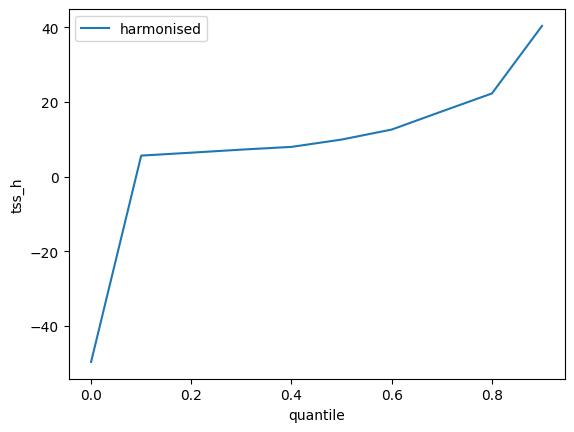

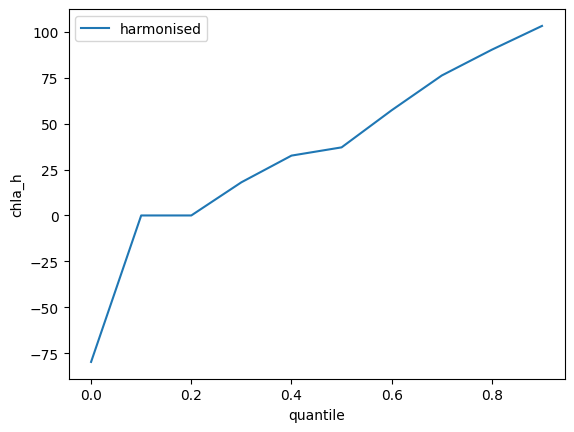

In [921]:
ds[['chla_h','tss_h']].isel(time=np.arange(0,10)).tss_h.quantile(np.arange(0,1,.1),dim=('x','y','time','tss_measure')).plot(label='harmonised')
#ds[['chla_h','tss_h']].isel(time=np.arange(0,10)).tss.quantile(np.arange(0,1,.1),dim=('x','y','time','tss_measure')).plot()
plt.legend()
plt.show()
ds[['chla_h','tss_h']].isel(time=np.arange(0,10)).chla_h.quantile(np.arange(0,1,.1),dim=('x','y','time','chla_measure')).plot(label='harmonised')
#ds[['chla_h','tss_h','chla','tss']].isel(time=np.arange(0,10)).chla.quantile(np.arange(0,1,.1),dim=('x','y','time','chla_measure')).plot()
plt.legend()
plt.show()


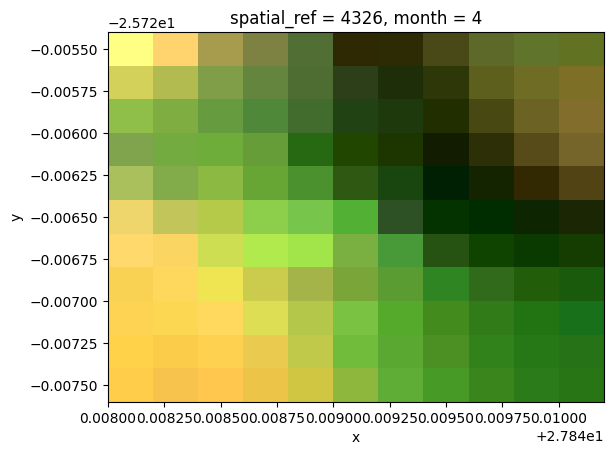

In [668]:
ds[['tm01','tm02','tm03']].to_array('tm').\
    groupby('time.month').\
    median(dim='time').\
    sel(month=4,tm=['tm03','tm02','tm01']).\
    plot.imshow(robust=True)

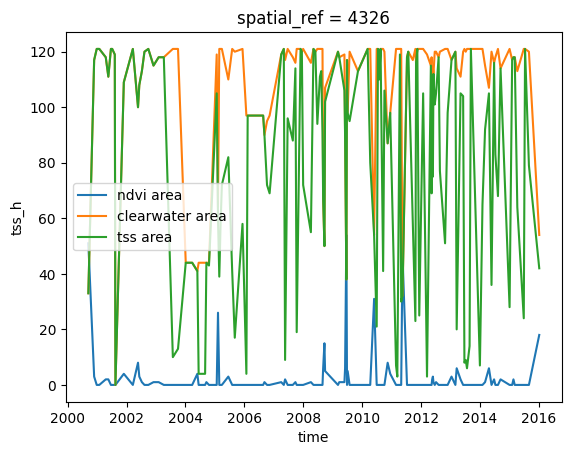

In [929]:

ds.ndvi.count(dim=('x','y')).plot(label='ndvi area')
ds.where(ds.clearwater==1).clearwater.count(dim=('x','y')).plot(label='clearwater area')
ds.tss_h.median(dim=('tss_measure')).count(dim=('x','y')).plot(label='tss area')
#ds.water_5yr.count(dim=('x','y')).plot(label='5 year water area')
#ds.tsm_lym_tm.count(dim=('x','y')).plot(label='tsm lym')
#ds.ndci_tm43.count(dim=('x','y')).plot(label='ndci_tm43')
plt.legend()
plt.show()


In [ ]:
# Famg's code...
mean_dfs = []
for i, year in enumerate(years):
    print(year)
    df_year = df[df["datetime"].dt.year==year]
    mean_df = (
        df_year.groupby(["GEMS Station Number", "Latitude", "Longitude"], as_index=False)
          ["Value"].mean()
    )
    mean_df["year"] = year

    if year <=2012:
        chla_bands = chla_tm
    elif year <2017:
        chla_bands = chla_oli
    else:
        chla_bands = chla_oli + chla_msi

    try:
        ds = dc.load(product='wq_annual', 
            lat = (df_year.Latitude.min()-0.001, df_year.Latitude.max()+0.001),
            lon = (df_year.Longitude.min()-0.001, df_year.Longitude.max()+0.001),
            time=f"{year}",
            measurements= chla_bands,
            resolution = (-0.0005, 0.0005),
            resampling = "nearest",
            output_crs = "EPSG:4326",
            dask_chunks={}).squeeze()

        vals = []
        for _, row in mean_df.iterrows():
            val = ds[chla_bands[0]].sel(latitude=row["Latitude"], longitude=row["Longitude"], method="nearest").values.item()*measurements.loc[chla_bands[0]]['scale_factor'] + measurements.loc[chla_bands[0]]['add_offset']
            n_bands = len(chla_bands)
            if n_bands >1:
                for band in chla_bands[1:]:
                    val += ds[band].sel(latitude=row["Latitude"], longitude=row["Longitude"], method="nearest").values.item()*measurements.loc[band]['scale_factor'] + measurements.loc[band]['add_offset']
                val = val/n_bands
            vals.append(val)
    except:
        vals = []
        
    mean_df["SatValue"] = vals
    mean_dfs.append(mean_df)

annual_df = pd.concat(mean_dfs, ignore_index=True)

#### Based on the  analysis below, for Chla limit the data to depths less than 2, or even 10 metres. The distributions diverge after that. 

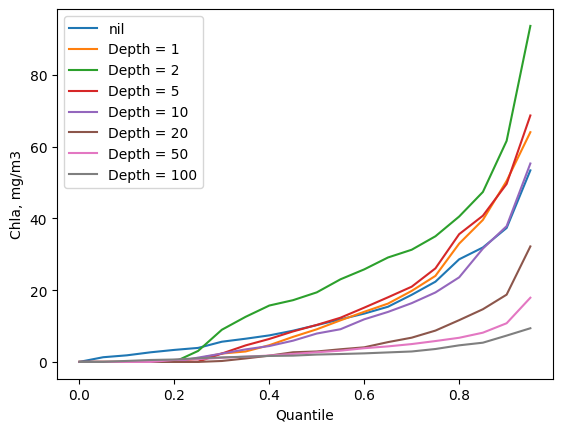

In [185]:
chla.loc[pd.isna(chla['Depth']),'Value'].quantile(Q).plot(label ='nil')

depths = [0,1,2,5,10,20,50,100]

for depth in depths[1:]:
    #print(depths[depths.index(depth)-1],depth)
    depth_data = chla.loc[(chla['Depth'] >= depths[depths.index(depth)-1]) & (chla['Depth'] < depth),'Value']
    depth_data.quantile(Q).plot(label='Depth = '+str(depth))
#    plt.axhline(depth_data.mean(),label='mean Chla, '+str(depth),linestyle=':')
plt.ylabel('Chla, mg/m3')
plt.xlabel('Quantile')

plt.legend(loc='upper left')
plt.show()
    #chla.loc[chla['Depth'] >= depths[depths.index(depth)-1] & chla['Depth'] < depth,'Value'].quantile(Q).plot(label=depth)


(0.0, 200.0)

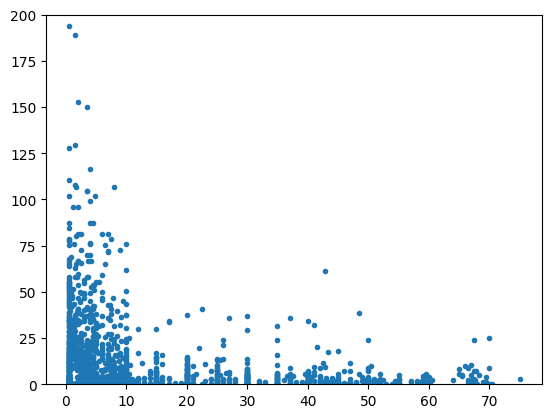

In [94]:
plt.plot(chla['Depth'],chla['Value'],linestyle='',marker='.')
plt.ylim(0,200)